# NB11 — Généralisation multi-problèmes : verdict et groupe de compétence (RQ2)
### Code Embeddings — Multi-Problem Generalization: Verdict & Proficiency Group (RQ2)

**Contexte.** Le notebook 10 a construit et exécuté un protocole en entonnoir sur un
seul problème (p02616) : la hiérarchie des signaux (langage $\gg$ problème $\gg$
difficulté $\approx$ verdict), puis, à problème et langage contrôlés, la conclusion
centrale — **CodeBERT n'apporte aucun avantage mesurable sur TF-IDF** pour prédire le
verdict par voisinage, y compris en Python, sa langue de pré-entraînement.

**Question de ce notebook.** Ce résultat tient-il sur un seul problème par hasard, ou
se généralise-t-il ? Et un axe jamais testé jusqu'ici : le **groupe de compétence**
de l'auteur (G1--G6) — promis dès la définition de RQ2 dans le README, jamais mesuré
en pratique — montre-t-il un signal plus net que le verdict ?

**Démarche.** Douze problèmes (trois par difficulté B--E, sélectionnés par volume de
soumissions), soumissions Python uniquement. Le criblage quantitatif (S2) couvre les
12 problèmes sans exception ; les cartes UMAP (S3, S4) sont utilisées avec parcimonie
— une carte poolée globale, puis des zooms uniquement sur les cas que le criblage
désigne comme extrêmes.

| Section | Contenu |
|---|---|
| **S0** | Génération (commande CLI multi-problèmes) |
| **S1** | Chargement du corpus (12 problèmes $\times$ Python) |
| **S2** | Criblage quantitatif — lift k-NN par problème, verdict et groupe |
| **S3** | Carte de répartition poolée (UMAP, 4 colorations) |
| **S4** | Zooms ciblés (UMAP par problème, cas désignés par S2) |
| **S5** | Synthèse |

---

**Context.** Notebook 10 built and ran a funnel protocol on a single problem
(p02616): the signal hierarchy (language $\gg$ problem $\gg$ difficulty $\approx$
verdict), then, with problem and language controlled, the central finding —
**CodeBERT shows no measurable advantage over TF-IDF** for predicting the verdict by
neighborhood, even in Python, its own pre-training language.

**This notebook's question.** Does this result hold on a single problem by chance, or
does it generalize? And an axis never tested so far: does the author's **proficiency
group** (G1--G6) — promised in RQ2's own definition, never actually measured — show a
cleaner signal than the verdict?

**Approach.** Twelve problems (three per difficulty B--E, selected by submission
volume), Python submissions only. The quantitative screening (S2) covers all 12
problems without exception; UMAP maps (S3, S4) are used sparingly — one pooled global
map, then zooms only on the cases the screening flags as extreme (see table above).

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

# Mêmes couleurs que 10_embeddings.ipynb, pour rester cohérent visuellement entre les deux notebooks
STATUS_COLORS = {
    'AC':  '#2ecc71',
    'WA':  '#e74c3c',
    'TLE': '#e67e22',
    'CE':  '#9b59b6',
    'RE':  '#3498db',
}
DIFF_COLORS = {'B': '#1abc9c', 'C': '#3498db', 'D': '#e74c3c', 'E': '#9b59b6'}
GROUP_COLORS = {
    'G1': '#c0392b', 'G2': '#e67e22', 'G3': '#f1c40f',
    'G4': '#2ecc71', 'G5': '#3498db', 'G6': '#9b59b6',
}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']
DIFFS_ORDER    = ['B', 'C', 'D', 'E']
GROUPS_ORDER   = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0 — Génération du corpus
### S0 — Corpus Generation

Douze problèmes (trois par difficulté, sélectionnés par volume de soumissions),
soumissions Python uniquement. Le CLI stratifie automatiquement par
(problème $\times$ verdict) dès que plusieurs `problem_id` sont donnés, pour que le
plus gros problème de la liste (p02658, 72,7k soumissions) ne domine pas le plus
petit (p02793, 19,8k).

```bash
python src/embedding.py tfidf cpu "Python" "p02658,p02718,p02922,p02659,p02623,p02761,p02642,p02714,p02900,p02616,p02574,p02793"
python src/embedding.py codebert mps "Python" "p02658,p02718,p02922,p02659,p02623,p02761,p02642,p02714,p02900,p02616,p02574,p02793"
```

Sorties attendues : `embeddings_tfidf_python_multi12.npy` / `embeddings_codebert_python_multi12.npy`
(et les `.csv` de métadonnées associés).

**Note.** Sur l'échantillon TF-IDF déjà généré (21 773 soumissions Python valides),
**CE (Compile Error) tombe à 0 sur les 12 problèmes** — Python étant interprété, il
n'a pas d'équivalent direct à une erreur de compilation C++. Les baselines de la
section S2 sont calculées par problème, sur les classes réellement présentes : ce
n'est donc pas un bug, mais un fait attendu à garder en tête pour l'interprétation
(4 verdicts effectifs pour Python : AC, WA, TLE, RE).

---

Twelve problems (three per difficulty, selected by submission volume), Python
submissions only. The CLI automatically stratifies by (problem $\times$ verdict) once
several `problem_id`s are given, so the largest problem in the list (p02658, 72.7k
submissions) doesn't dominate the smallest (p02793, 19.8k).

**Note.** On the already-generated TF-IDF sample (21,773 valid Python submissions),
**CE (Compile Error) is 0 across all 12 problems** — Python being interpreted, it has
no direct equivalent to a C++ compilation error. S2's baselines are computed per
problem, over the classes actually present, so this isn't a bug — just an expected
fact to keep in mind when interpreting results (4 effective verdicts for Python: AC,
WA, TLE, RE).

## S1 — Chargement du corpus
### S1 — Loading the Corpus

In [2]:
METHODS_MULTI = ["tfidf_python_multi12", "codebert_python_multi12"]

embeddings_multi = {}
df_meta_multi    = {}

for m in METHODS_MULTI:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {m} — lancer la commande de S0")
        continue
    embeddings_multi[m] = np.load(emb_path)
    df_meta_multi[m]    = pl.read_csv(meta_path)
    meta = df_meta_multi[m]
    print(f"{m:28s} : {embeddings_multi[m].shape}  |  {meta.height:,} soumissions  "
          f"|  {meta['problem_id'].n_unique()} problèmes  |  {meta['proficiency_group'].n_unique()} groupes")

print(f"\nMéthodes chargées : {list(embeddings_multi.keys())}")

tfidf_python_multi12         : (21773, 10000)  |  21,773 soumissions  |  12 problèmes  |  6 groupes
codebert_python_multi12      : (21773, 768)  |  21,773 soumissions  |  12 problèmes  |  6 groupes

Méthodes chargées : ['tfidf_python_multi12', 'codebert_python_multi12']


## S2 — Criblage quantitatif : lift k-NN par problème
### S2 — Quantitative Screening: k-NN Lift per Problem

Pour chaque problème, on **restreint l'espace aux seules soumissions de ce
problème** puis on recalcule le k-NN localement — exactement la méthode du problème
contrôlé de NB10 (S4), répétée sur les 12 problèmes plutôt que sur un seul. On ne
réutilise pas les voisins du corpus poolé (dominés par le clivage inter-problèmes,
cf. NB10 S2.1, lift $\times$26,8) : ce serait mesurer autre chose.

Deux étiquettes par problème : `status_code` (verdict) et `proficiency_group`
(groupe de compétence, jamais testé jusqu'ici). Baseline Σp² calculée séparément
pour chaque problème, sur les classes réellement présentes dans son sous-échantillon.

---

For each problem, the space is **restricted to that problem's submissions only**,
then k-NN is recomputed locally — exactly NB10's controlled-problem method (S4),
repeated across 12 problems instead of one. Neighbors from the pooled corpus are
not reused (dominated by the between-problem split, cf. NB10 S2.1, lift
$\times$26.8): that would measure something else.

Two labels per problem: `status_code` (verdict) and `proficiency_group` (competence
group, never tested so far). Σp² baseline computed separately for each problem, over
the classes actually present in its subsample.

In [3]:
from sklearn.neighbors import NearestNeighbors

K = 10
TARGET_LABELS_S2 = ['status_code', 'proficiency_group']
LABEL_NAMES_S2   = {'status_code': 'verdict', 'proficiency_group': 'groupe'}

s2_rows = []
for m in METHODS_MULTI:
    if m not in embeddings_multi:
        continue
    emb, meta = embeddings_multi[m], df_meta_multi[m]
    problems = meta.select(['problem_id', 'difficulty']).unique().sort('problem_id')
    print(f"\n{m} — criblage sur {problems.height} problèmes...")

    for row in problems.iter_rows(named=True):
        pid, diff = row['problem_id'], row['difficulty']
        idx_pid = np.where((meta['problem_id'] == pid).to_numpy())[0]
        if len(idx_pid) < K + 1:
            print(f"  {pid} : trop peu de soumissions ({len(idx_pid)}) — ignoré")
            continue

        sub_emb = emb[idx_pid]
        k_eff = min(K, len(idx_pid) - 1)
        nbrs = NearestNeighbors(n_neighbors=k_eff + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for label in TARGET_LABELS_S2:
            labels_arr = meta[label].to_numpy()[idx_pid]
            cons = float(np.mean([
                np.sum(labels_arr[nn_idx[i, 1:]] == labels_arr[i]) / k_eff
                for i in range(len(labels_arr))
            ]))
            probs = pl.Series(labels_arr).value_counts()['count'].to_numpy() / len(labels_arr)
            base  = float(np.sum(probs ** 2))
            s2_rows.append({
                'method': m, 'problem_id': pid, 'difficulty': diff, 'label': label,
                'n': len(labels_arr), 'consistency': cons, 'baseline': base,
                'lift': cons / base if base > 0 else float('nan'),
            })

df_s2 = pl.DataFrame(s2_rows)
n_methods = df_s2['method'].n_unique() if df_s2.height else 0
n_probs   = df_s2['problem_id'].n_unique() if df_s2.height else 0
print(f"\n{df_s2.height} lignes de résultats ({n_methods} méthode(s) × {n_probs} problèmes × {len(TARGET_LABELS_S2)} étiquettes)")


tfidf_python_multi12 — criblage sur 12 problèmes...

codebert_python_multi12 — criblage sur 12 problèmes...

48 lignes de résultats (2 méthode(s) × 12 problèmes × 2 étiquettes)


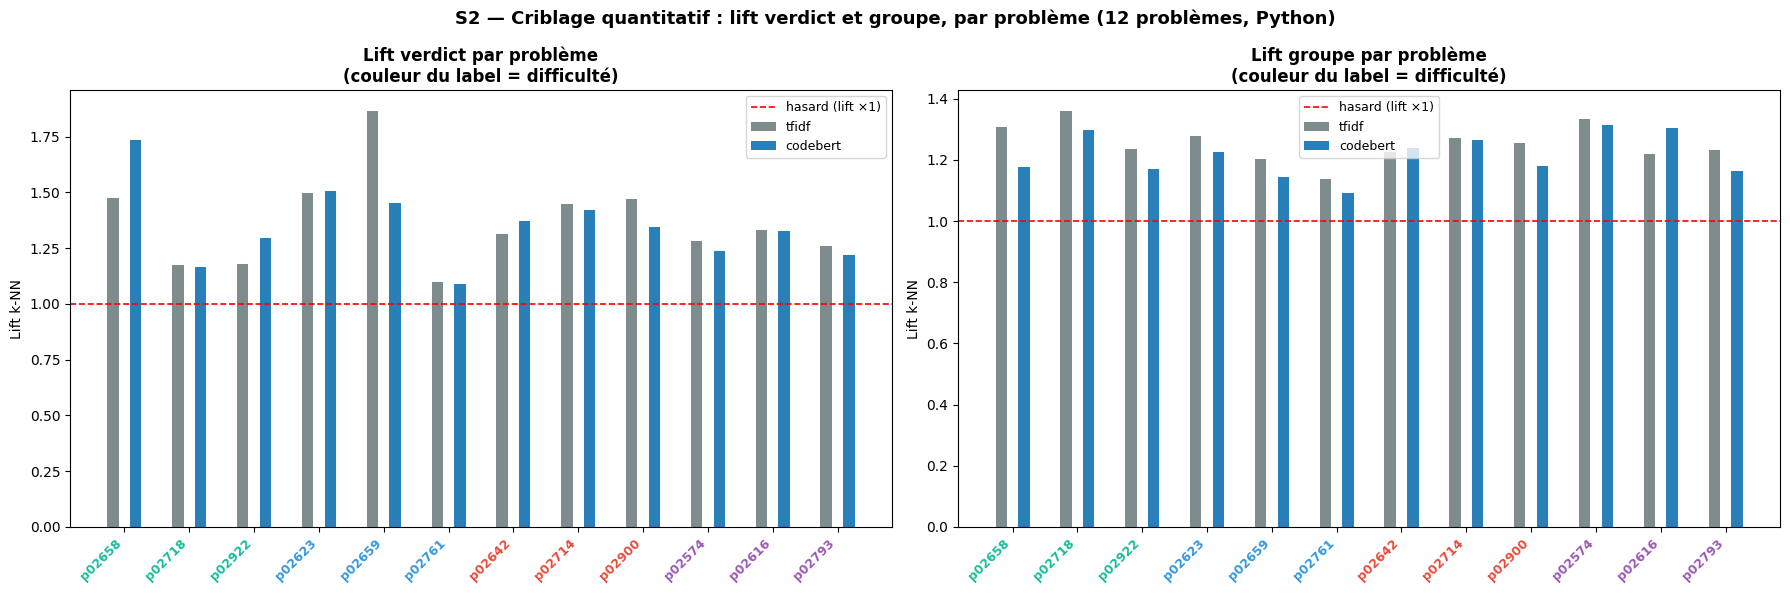

In [4]:
problems_ordered = (
    df_s2.select(['problem_id', 'difficulty']).unique().sort(['difficulty', 'problem_id'])
)
pid_list  = problems_ordered['problem_id'].to_list()
diff_list = problems_ordered['difficulty'].to_list()

method_colors = {'tfidf_python_multi12': '#7f8c8d', 'codebert_python_multi12': '#2980b9'}
methods_present = [m for m in METHODS_MULTI if m in embeddings_multi]

fig, axes = plt.subplots(1, len(TARGET_LABELS_S2), figsize=(9 * len(TARGET_LABELS_S2), 6))
if len(TARGET_LABELS_S2) == 1:
    axes = [axes]

x = np.arange(len(pid_list))
width = 0.35 if len(methods_present) > 1 else 0.6

for ax, label in zip(axes, TARGET_LABELS_S2):
    sub = df_s2.filter(pl.col('label') == label)
    offsets = np.linspace(-width / 2, width / 2, len(methods_present)) if len(methods_present) > 1 else [0]

    for off, m in zip(offsets, methods_present):
        vals = []
        for pid in pid_list:
            row = sub.filter((pl.col('problem_id') == pid) & (pl.col('method') == m))
            vals.append(row['lift'][0] if row.height else np.nan)
        ax.bar(x + off, vals, width / max(len(methods_present), 1),
               label=m.replace('_python_multi12', ''), color=method_colors.get(m, '#333'))

    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='hasard (lift ×1)')
    ax.set_xticks(x)
    ax.set_xticklabels(pid_list, rotation=45, ha='right', fontsize=9)
    for tick, diff in zip(ax.get_xticklabels(), diff_list):
        tick.set_color(DIFF_COLORS.get(diff, 'black'))
        tick.set_fontweight('bold')
    ax.set_ylabel('Lift k-NN')
    ax.set_title(f'Lift {LABEL_NAMES_S2[label]} par problème\n(couleur du label = difficulté)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('S2 — Criblage quantitatif : lift verdict et groupe, par problème (12 problèmes, Python)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## S3 — Carte de répartition poolée
### S3 — Pooled Distribution Map

Une seule carte UMAP par méthode, ajustée sur les 12 problèmes réunis, colorée
successivement par problème, verdict, difficulté et groupe de compétence. Sert de
vue d'ensemble qualitative — à lire avec prudence : un signal invisible ici peut
exister quand même (une UMAP écrase 768 dimensions en 2, cf. NB10 S2.2 vs S2.1),
c'est le criblage S2 qui fait foi.

---

One UMAP map per method, fit on all 12 problems pooled, colored in turn by problem,
verdict, difficulty and proficiency group. A qualitative overview — read with
caution: a signal invisible here may still exist (UMAP collapses 768 dimensions into
2, cf. NB10 S2.2 vs S2.1); the S2 screening is the authoritative measure.

Fit UMAP — tfidf_python_multi12 (21773 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  tfidf_python_multi12 : fait.
Fit UMAP — codebert_python_multi12 (21773 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  codebert_python_multi12 : fait.


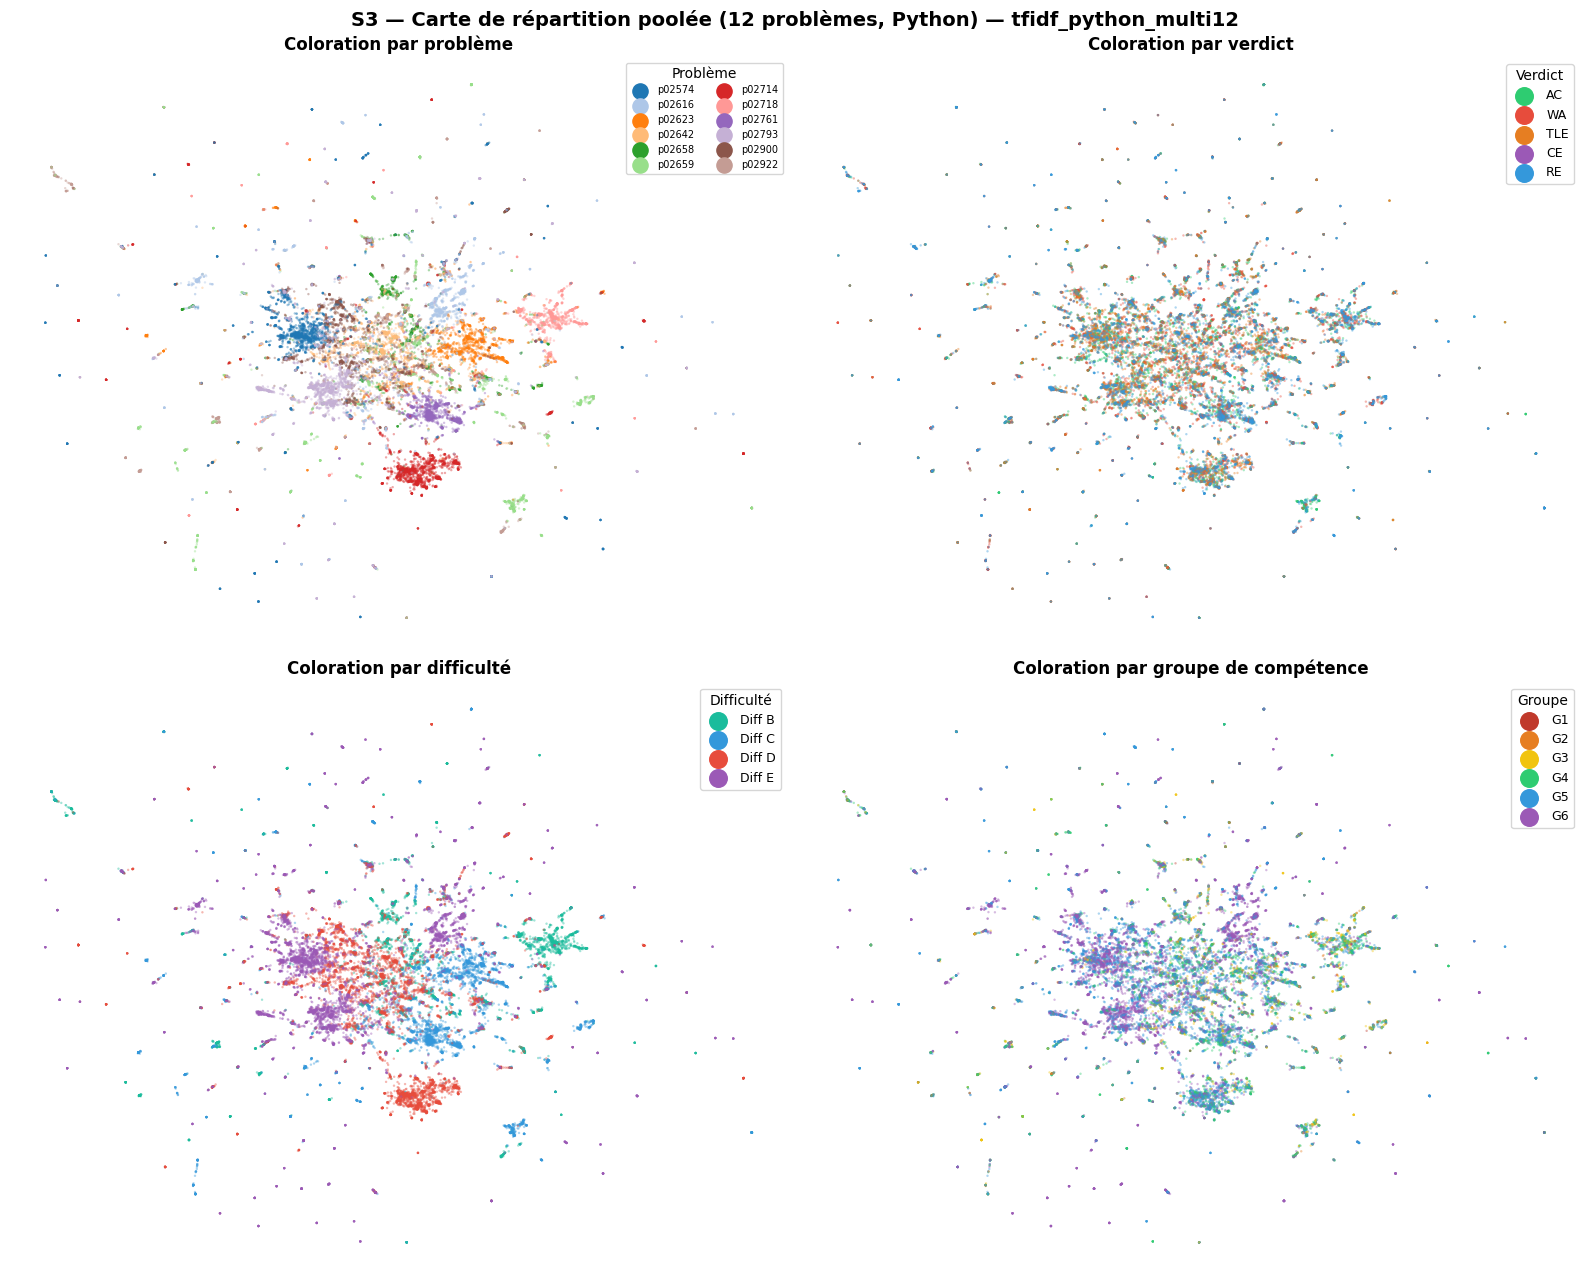

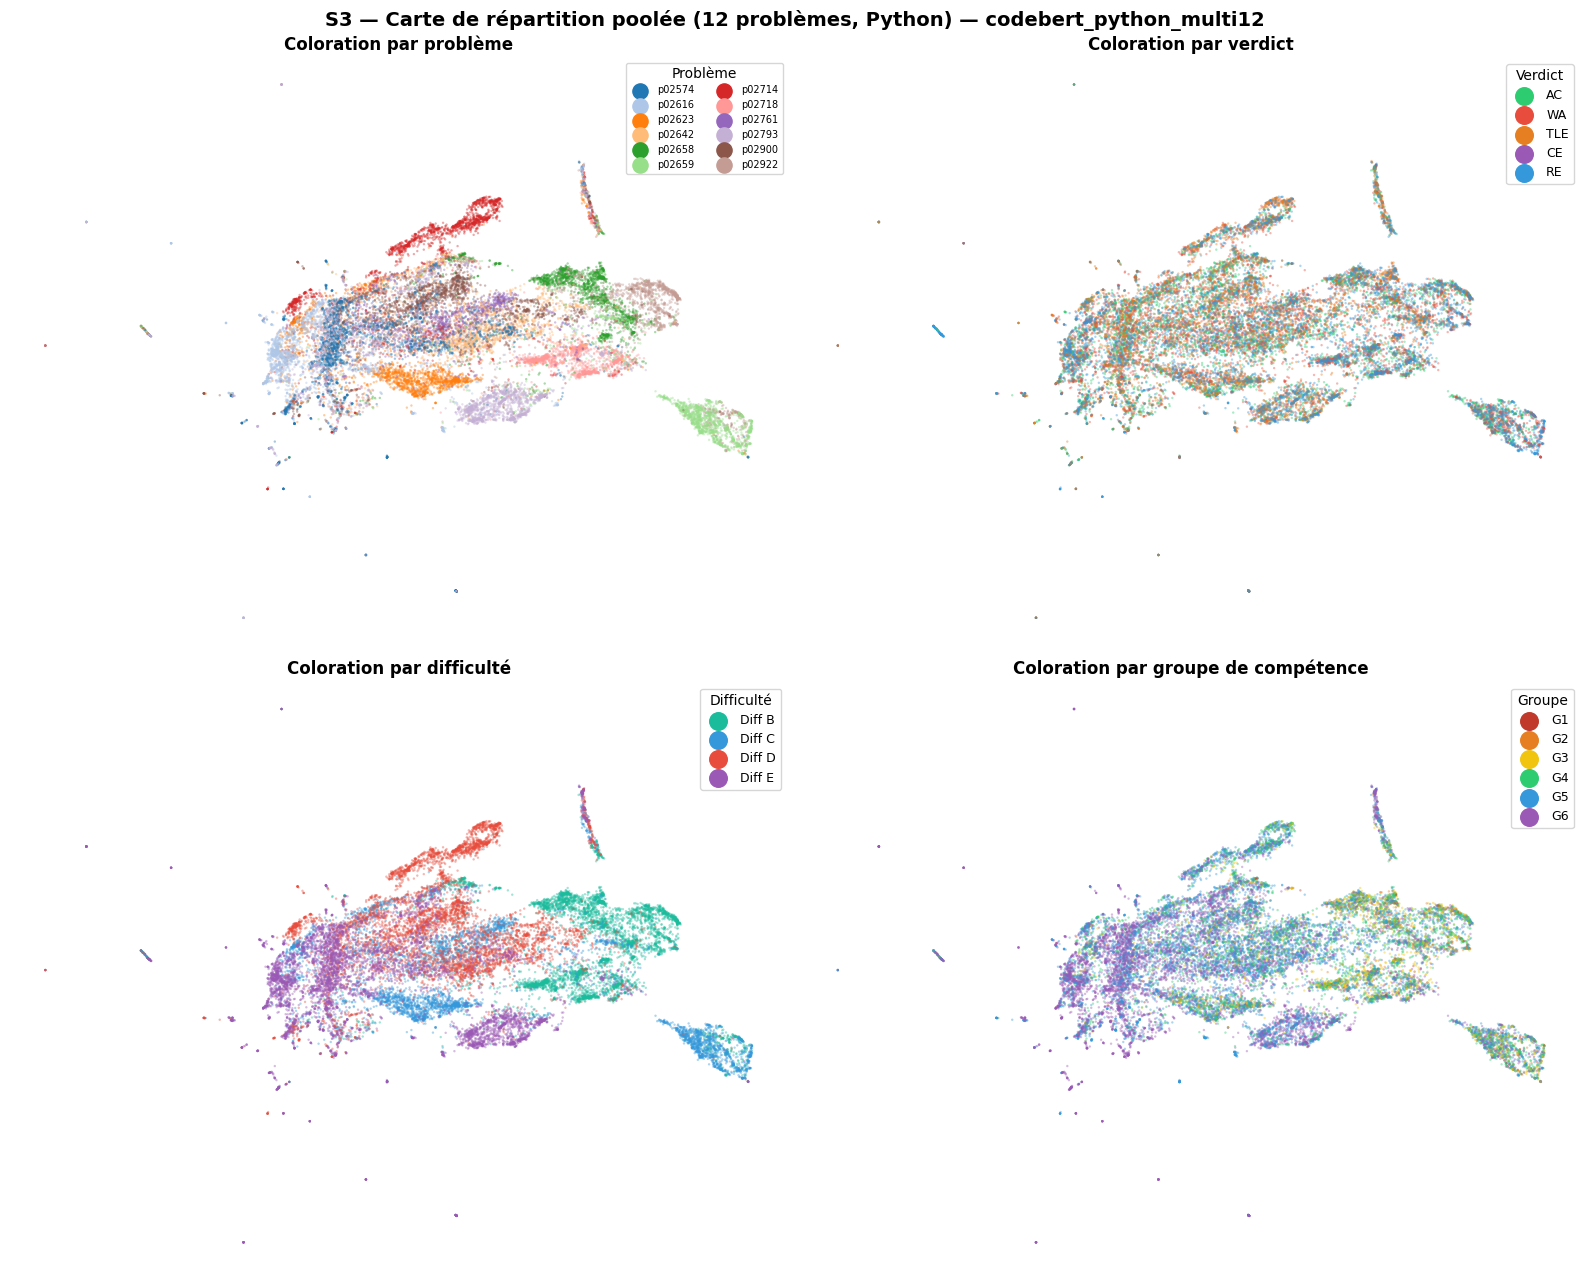

In [5]:
umap_2d_multi = {}

try:
    import umap

    for m in METHODS_MULTI:
        if m not in embeddings_multi:
            continue
        print(f"Fit UMAP — {m} ({embeddings_multi[m].shape[0]} points)...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
        umap_2d_multi[m] = reducer.fit_transform(embeddings_multi[m])
        print(f"  {m} : fait.")

    palette = plt.cm.tab20.colors

    for m in [m for m in METHODS_MULTI if m in umap_2d_multi]:
        meta, proj = df_meta_multi[m], umap_2d_multi[m]
        fig, axes = plt.subplots(2, 2, figsize=(16, 13))

        # Problème
        pids = sorted(meta['problem_id'].unique().to_list())
        pid_color = {p: palette[i % 20] for i, p in enumerate(pids)}
        ax = axes[0, 0]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[pid_color[p] for p in meta['problem_id'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for p in pids:
            ax.scatter([], [], c=[pid_color[p]], s=30, label=p)
        ax.legend(title='Problème', fontsize=7, markerscale=2, framealpha=0.8, ncol=2)
        ax.set_title('Coloration par problème', fontsize=12, fontweight='bold')
        ax.axis('off')

        # Verdict
        ax = axes[0, 1]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[STATUS_COLORS.get(s, '#aaaaaa') for s in meta['status_code'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for s, c in STATUS_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=s)
        ax.legend(title='Verdict', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title('Coloration par verdict', fontsize=12, fontweight='bold')
        ax.axis('off')

        # Difficulté
        ax = axes[1, 0]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[DIFF_COLORS.get(d, '#aaaaaa') for d in meta['difficulty'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for d, c in DIFF_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=f'Diff {d}')
        ax.legend(title='Difficulté', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title('Coloration par difficulté', fontsize=12, fontweight='bold')
        ax.axis('off')

        # Groupe de compétence
        ax = axes[1, 1]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[GROUP_COLORS.get(g, '#aaaaaa') for g in meta['proficiency_group'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for g, c in GROUP_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=g)
        ax.legend(title='Groupe', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title('Coloration par groupe de compétence', fontsize=12, fontweight='bold')
        ax.axis('off')

        fig.suptitle(f'S3 — Carte de répartition poolée (12 problèmes, Python) — {m}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

except ImportError:
    print("UMAP non installé — pip install umap-learn")

## S4 — Galerie complète par difficulté
### S4 — Full Gallery by Difficulty

Les 12 problèmes, un par un, regroupés en quatre sous-sections (une par difficulté).
Pour chaque problème : une figure unique, grille 2$\times$2 — méthode (TF-IDF /
CodeBERT) en ligne, étiquette (verdict / groupe) en colonne — pour comparer
directement les deux méthodes sur les deux axes.

**Rappel de lecture.** C'est le criblage quantitatif (S2) qui fait foi, pas l'œil :
sur 12 figures denses, un nuage qui "a l'air" séparé visuellement peut très bien
être proche de la baseline hasard, et inversement. Utiliser les valeurs de lift de
S2 comme guide pour savoir quels problèmes regarder en priorité dans cette galerie.

---

All 12 problems, one by one, grouped into four subsections (one per difficulty).
For each problem: a single figure, 2$\times$2 grid — method (TF-IDF / CodeBERT) as
rows, label (verdict / group) as columns — to directly compare both methods on both
axes.

**Reading reminder.** The quantitative screening (S2) is authoritative, not the eye:
across 12 dense figures, a cluster that "looks" separated may well sit close to the
random baseline, and vice versa. Use S2's lift values as a guide to which problems
deserve priority attention in this gallery.

verdict  — lift le plus fort  : p02659 (×1.87, tfidf_python_multi12)
verdict  — lift le plus faible : p02761 (×1.09, codebert_python_multi12)
groupe   — lift le plus fort  : p02718 (×1.36, tfidf_python_multi12)
groupe   — lift le plus faible : p02761 (×1.09, codebert_python_multi12)


### Difficulté B — p02658, p02718, p02922
### Difficulty B — p02658, p02718, p02922

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


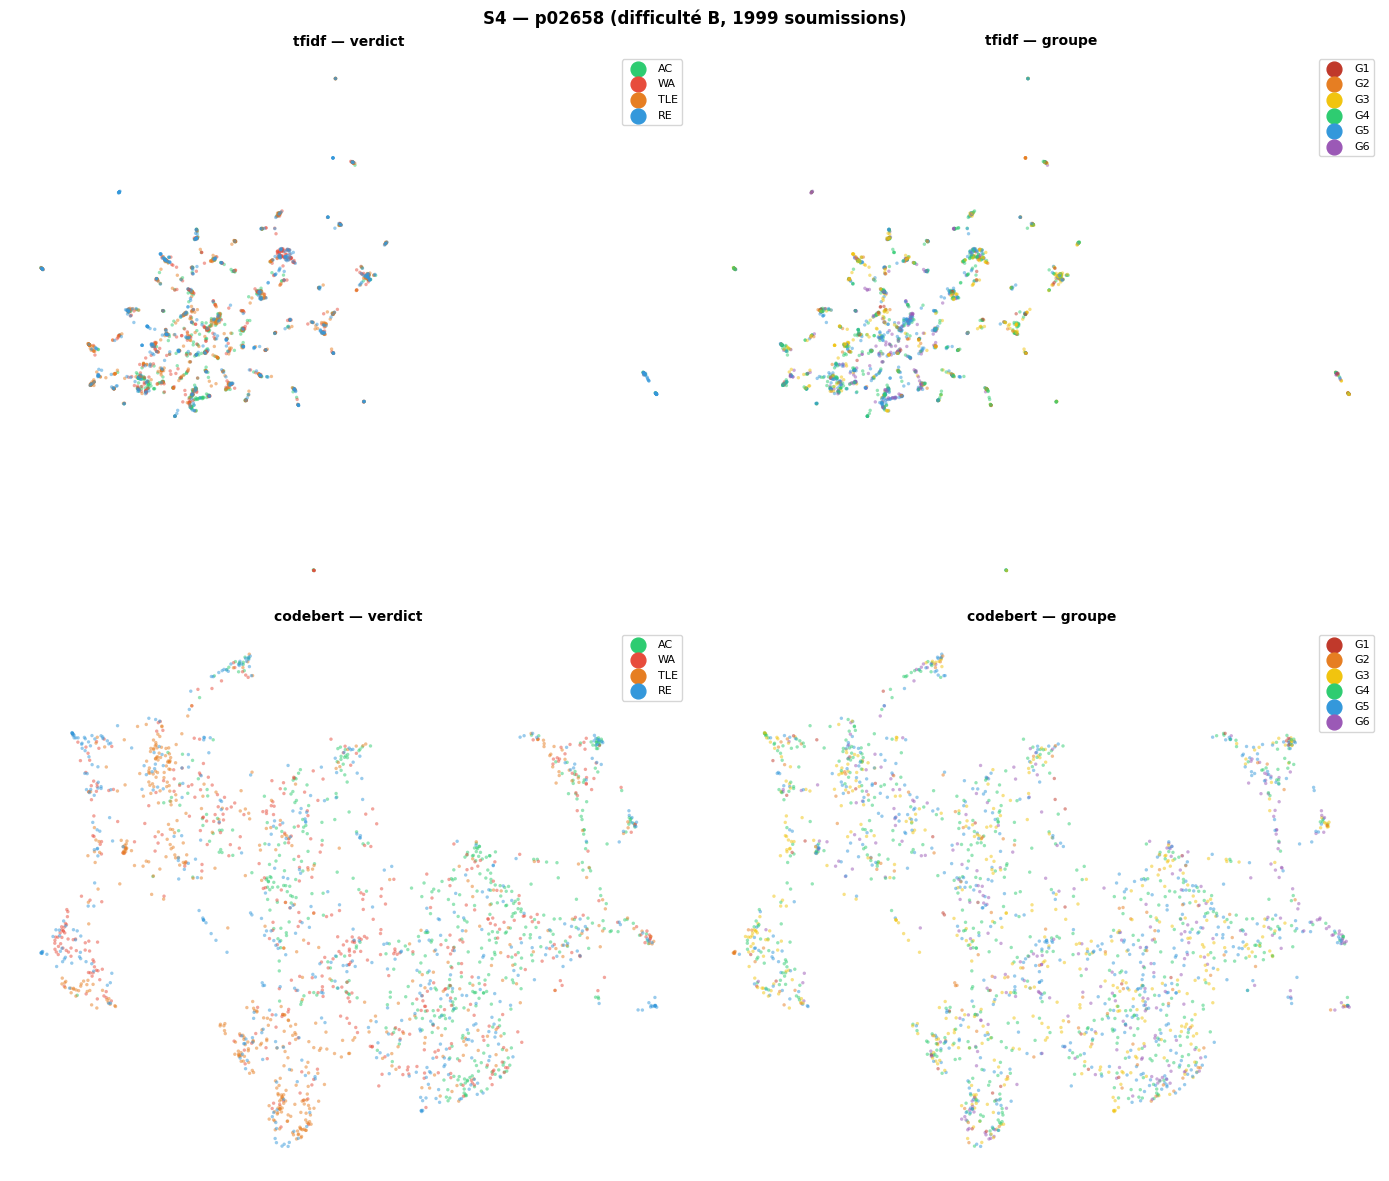

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


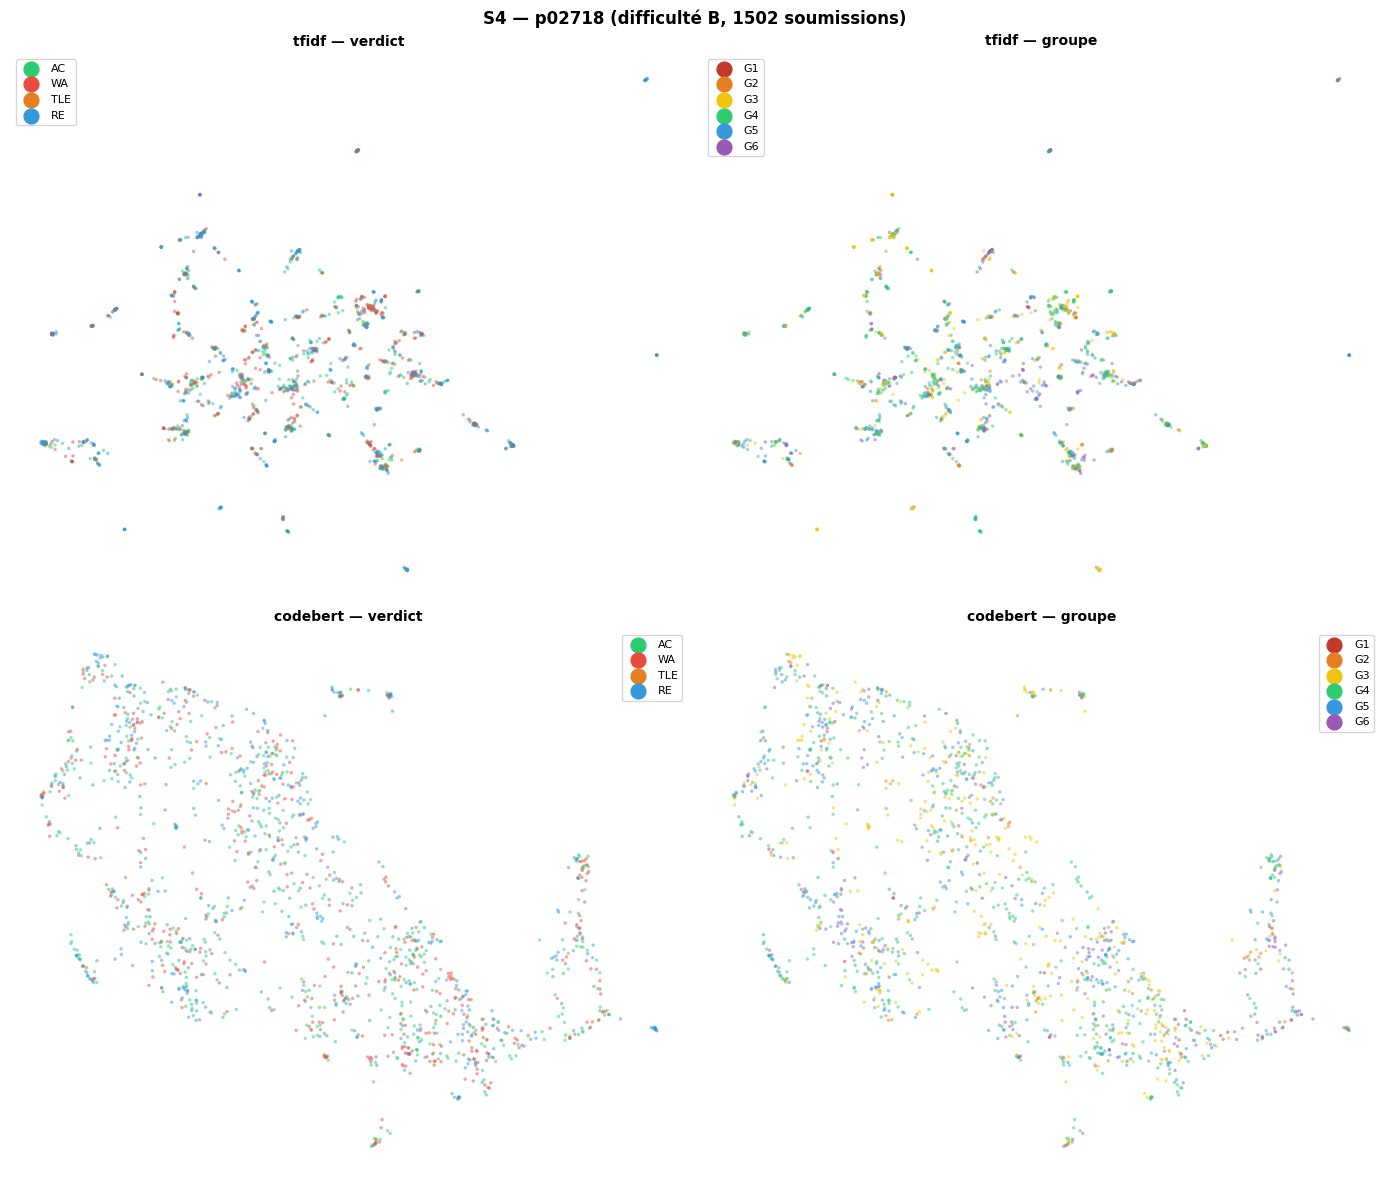

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


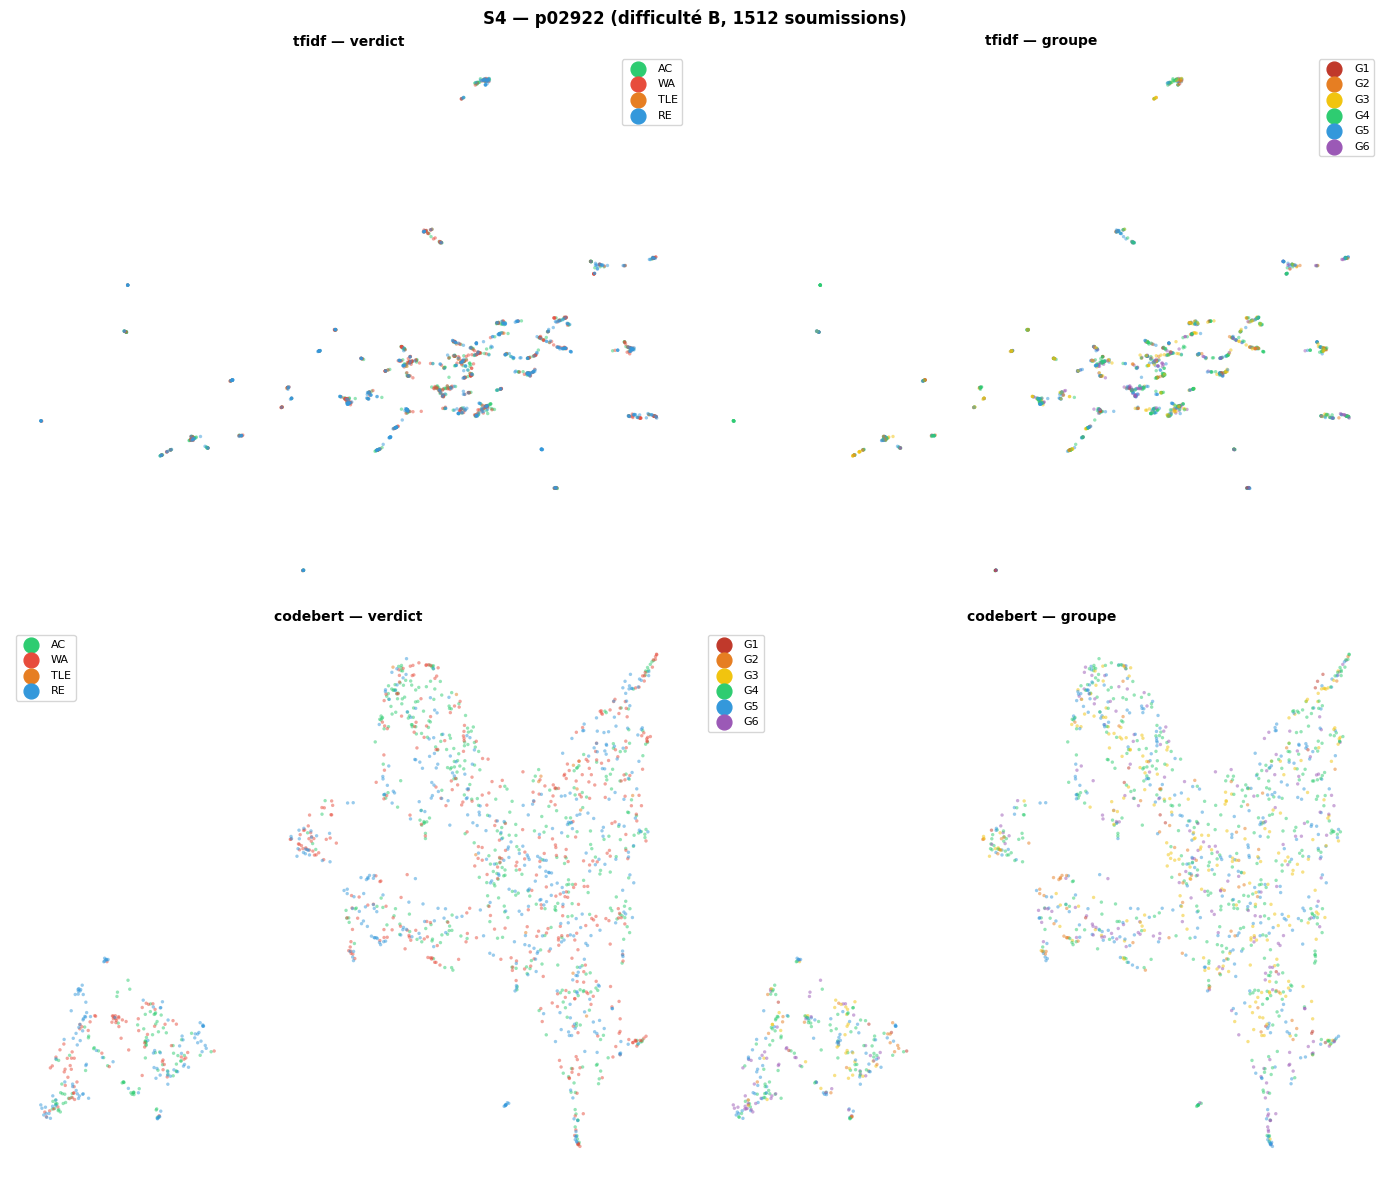

### Difficulté C — p02623, p02659, p02761
### Difficulty C — p02623, p02659, p02761

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


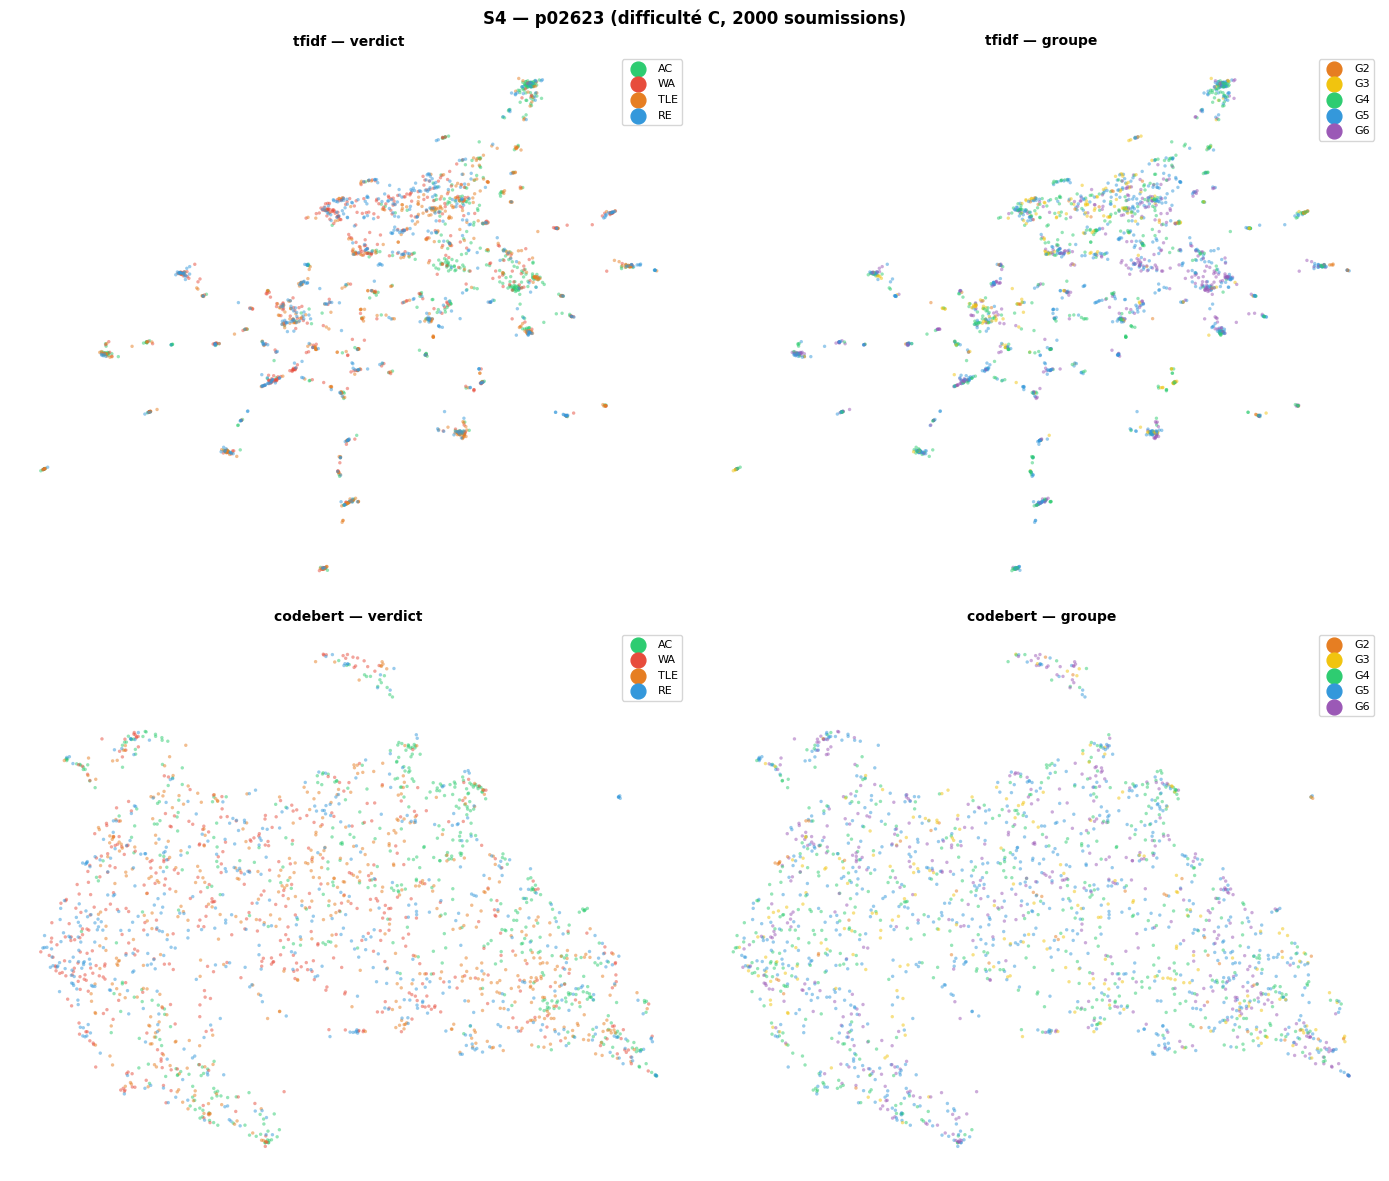

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


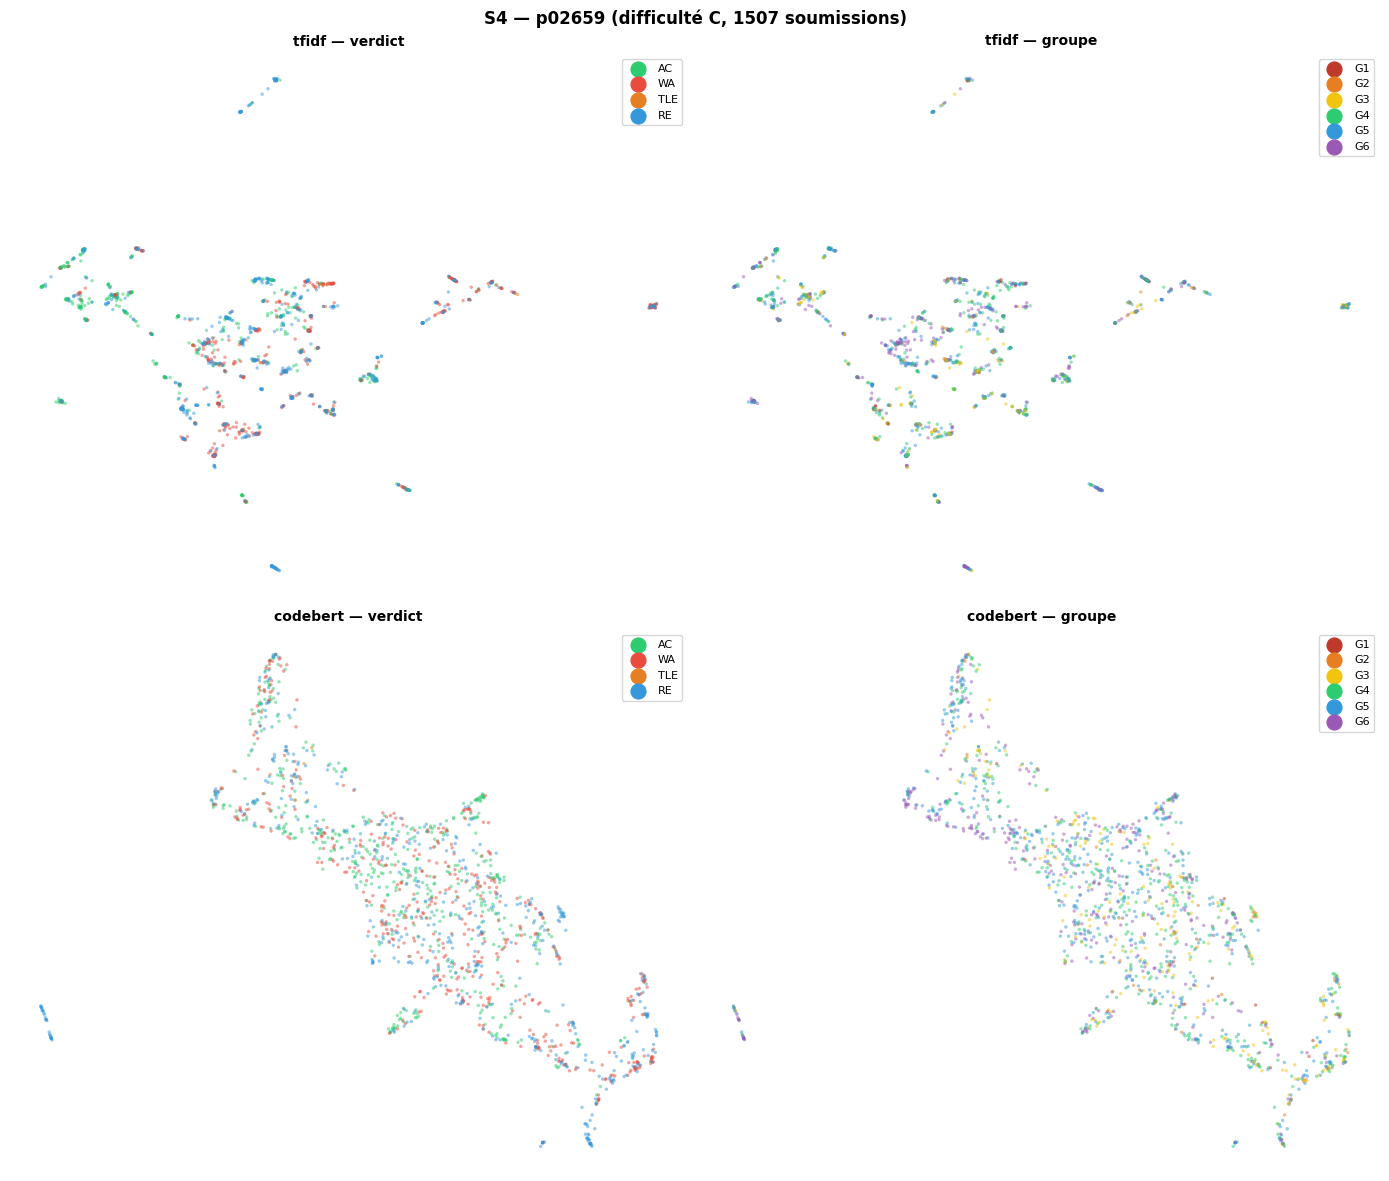

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


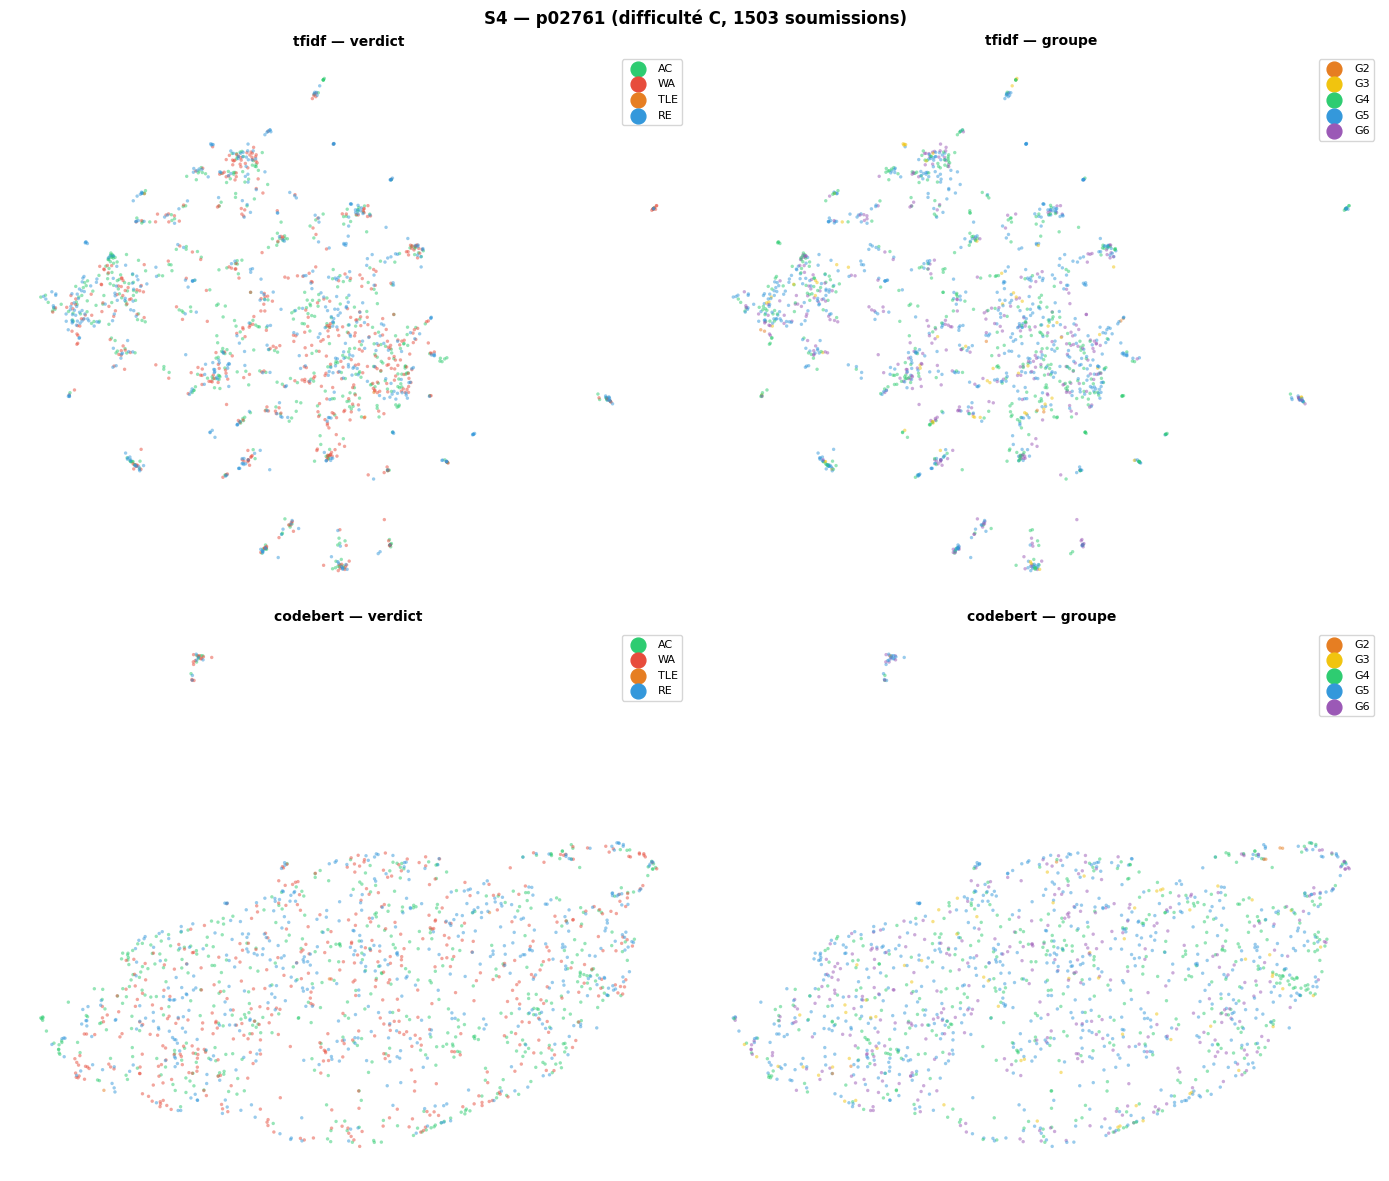

### Difficulté D — p02642, p02714, p02900
### Difficulty D — p02642, p02714, p02900

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


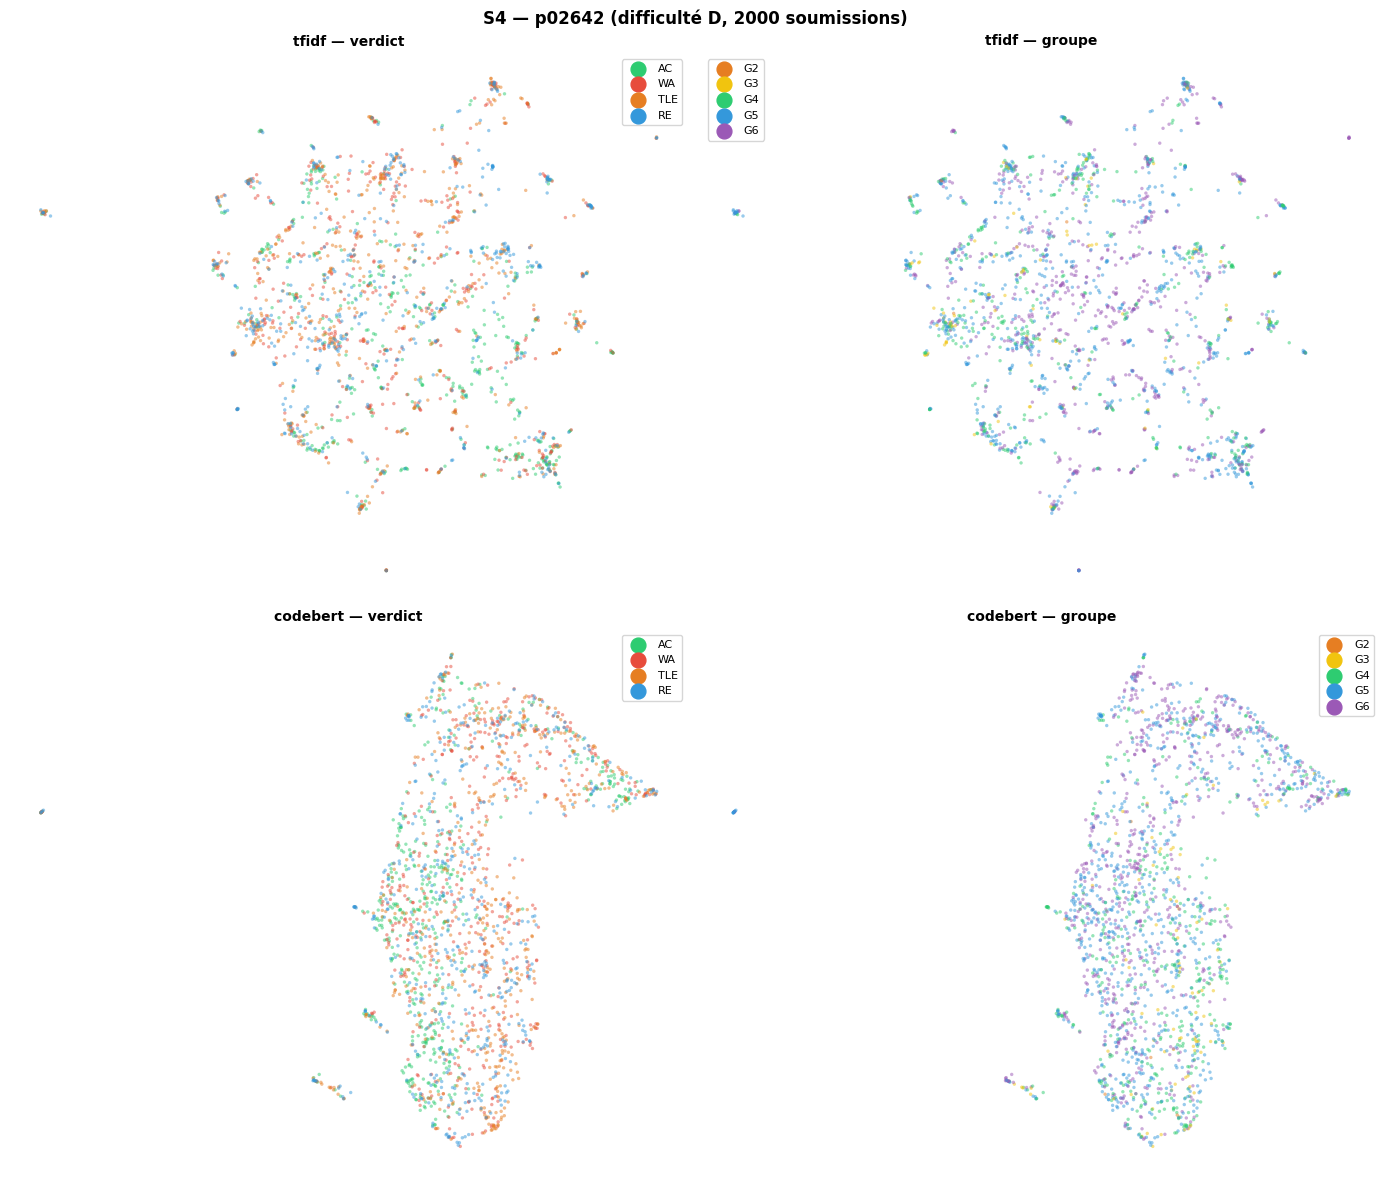

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


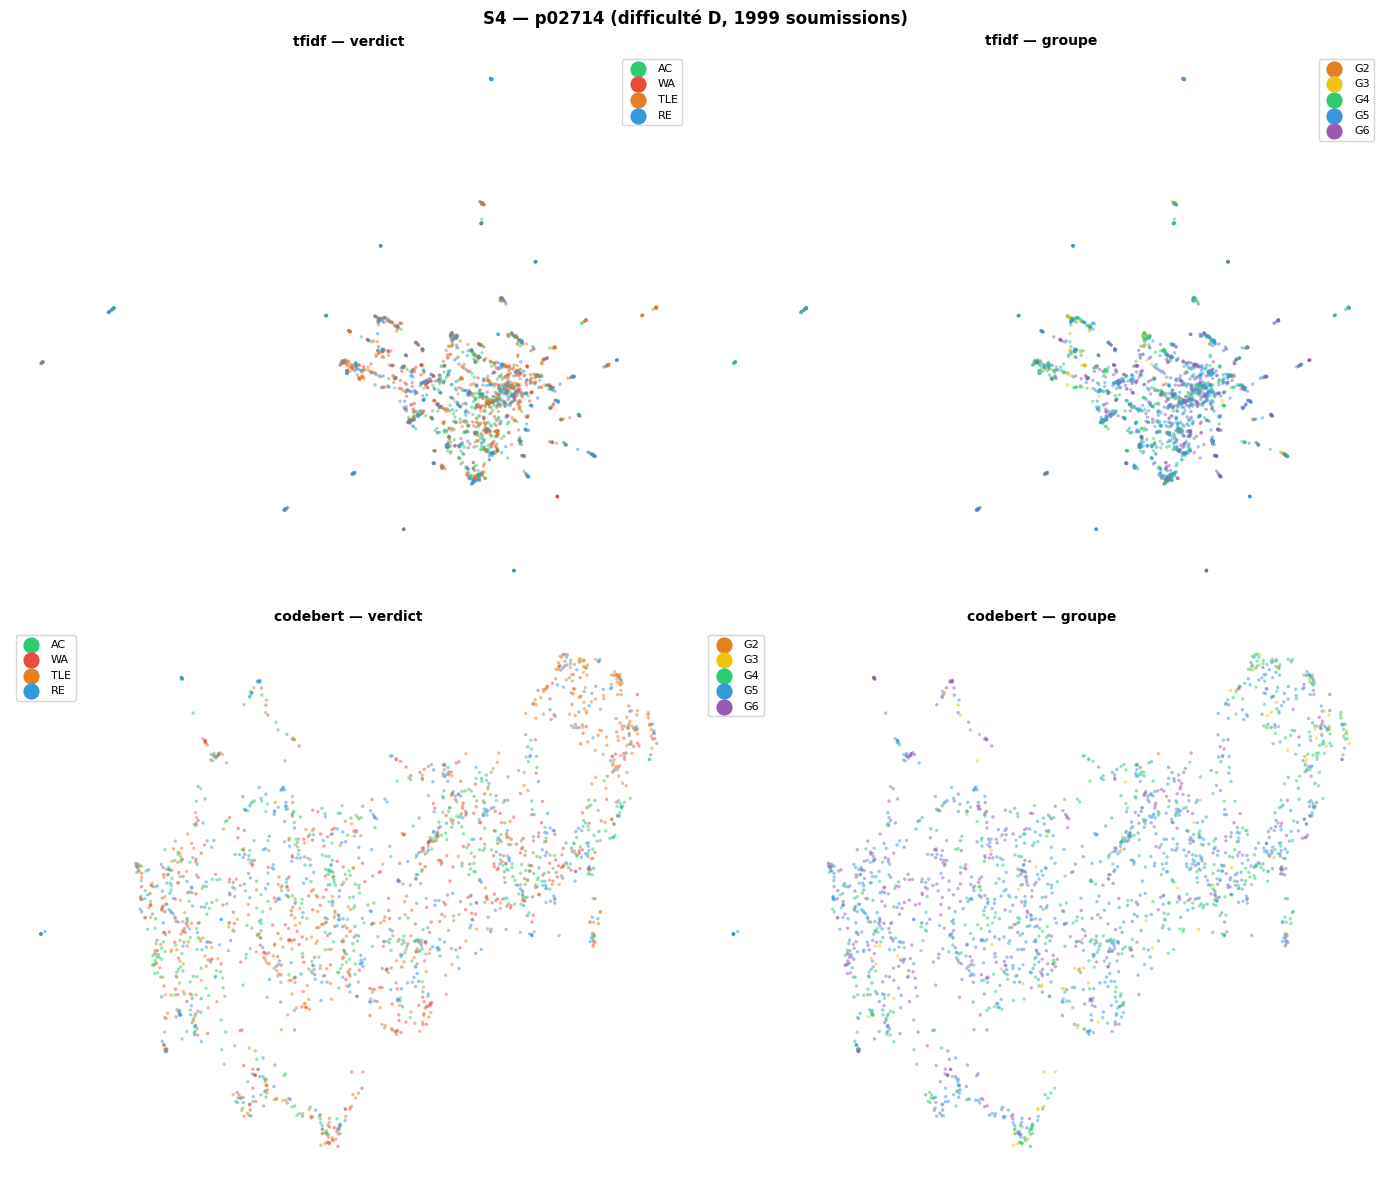

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


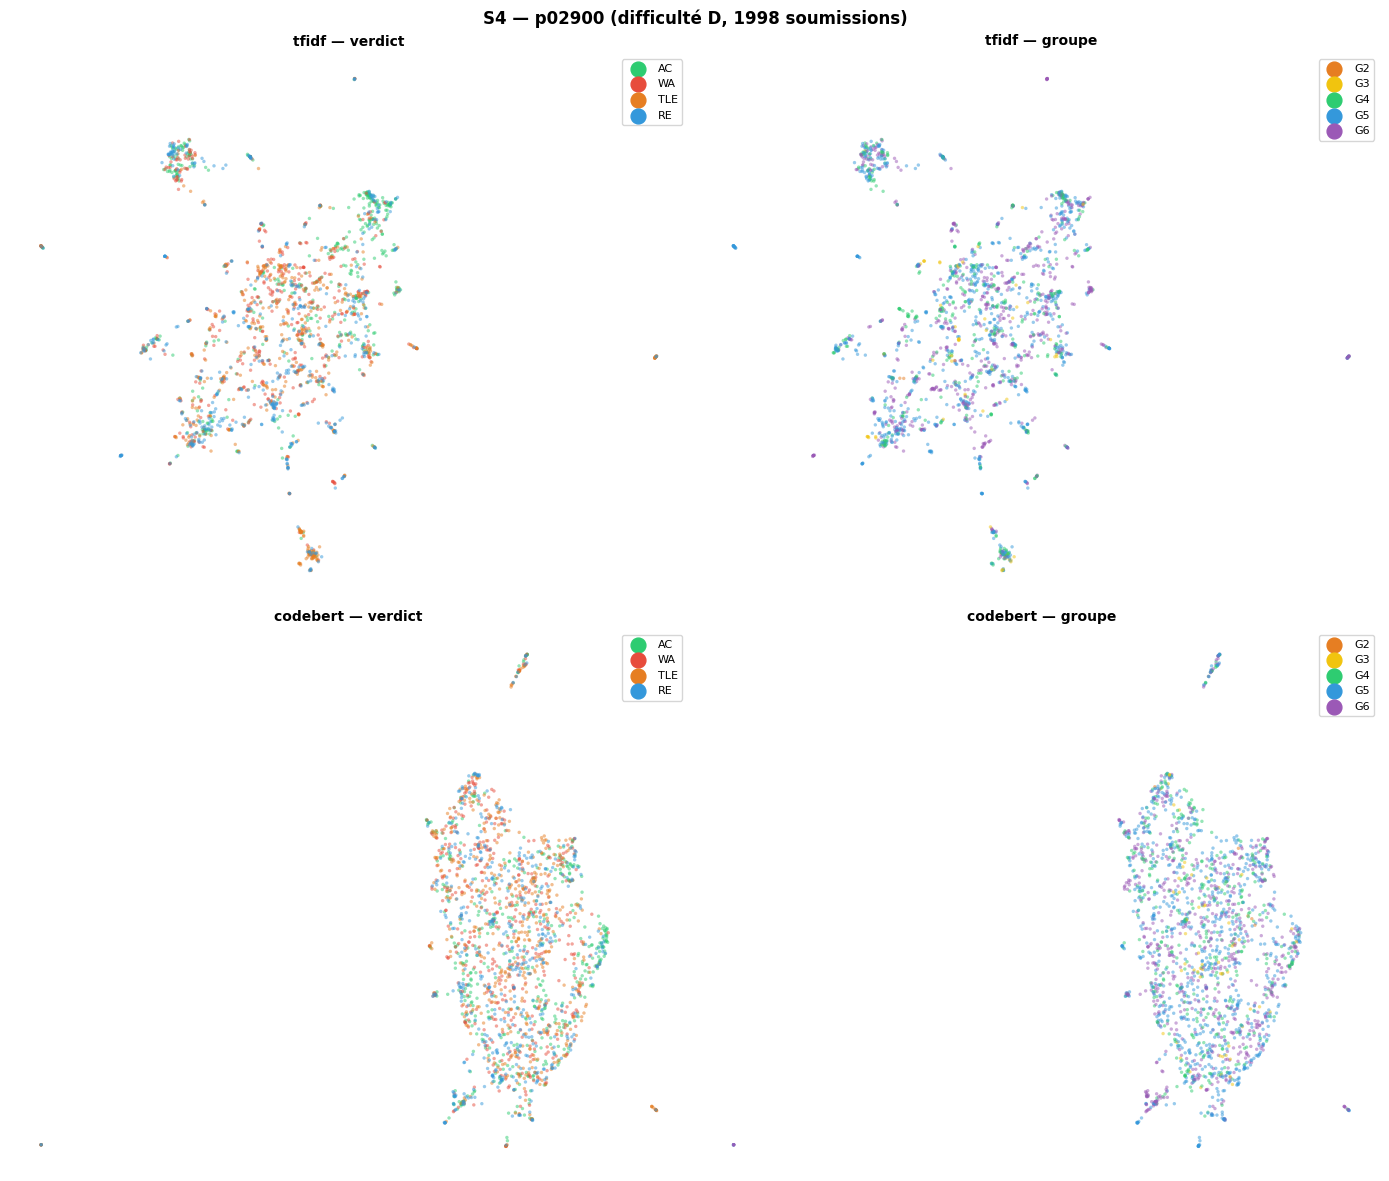

### Difficulté E — p02574, p02616, p02793
### Difficulty E — p02574, p02616, p02793

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


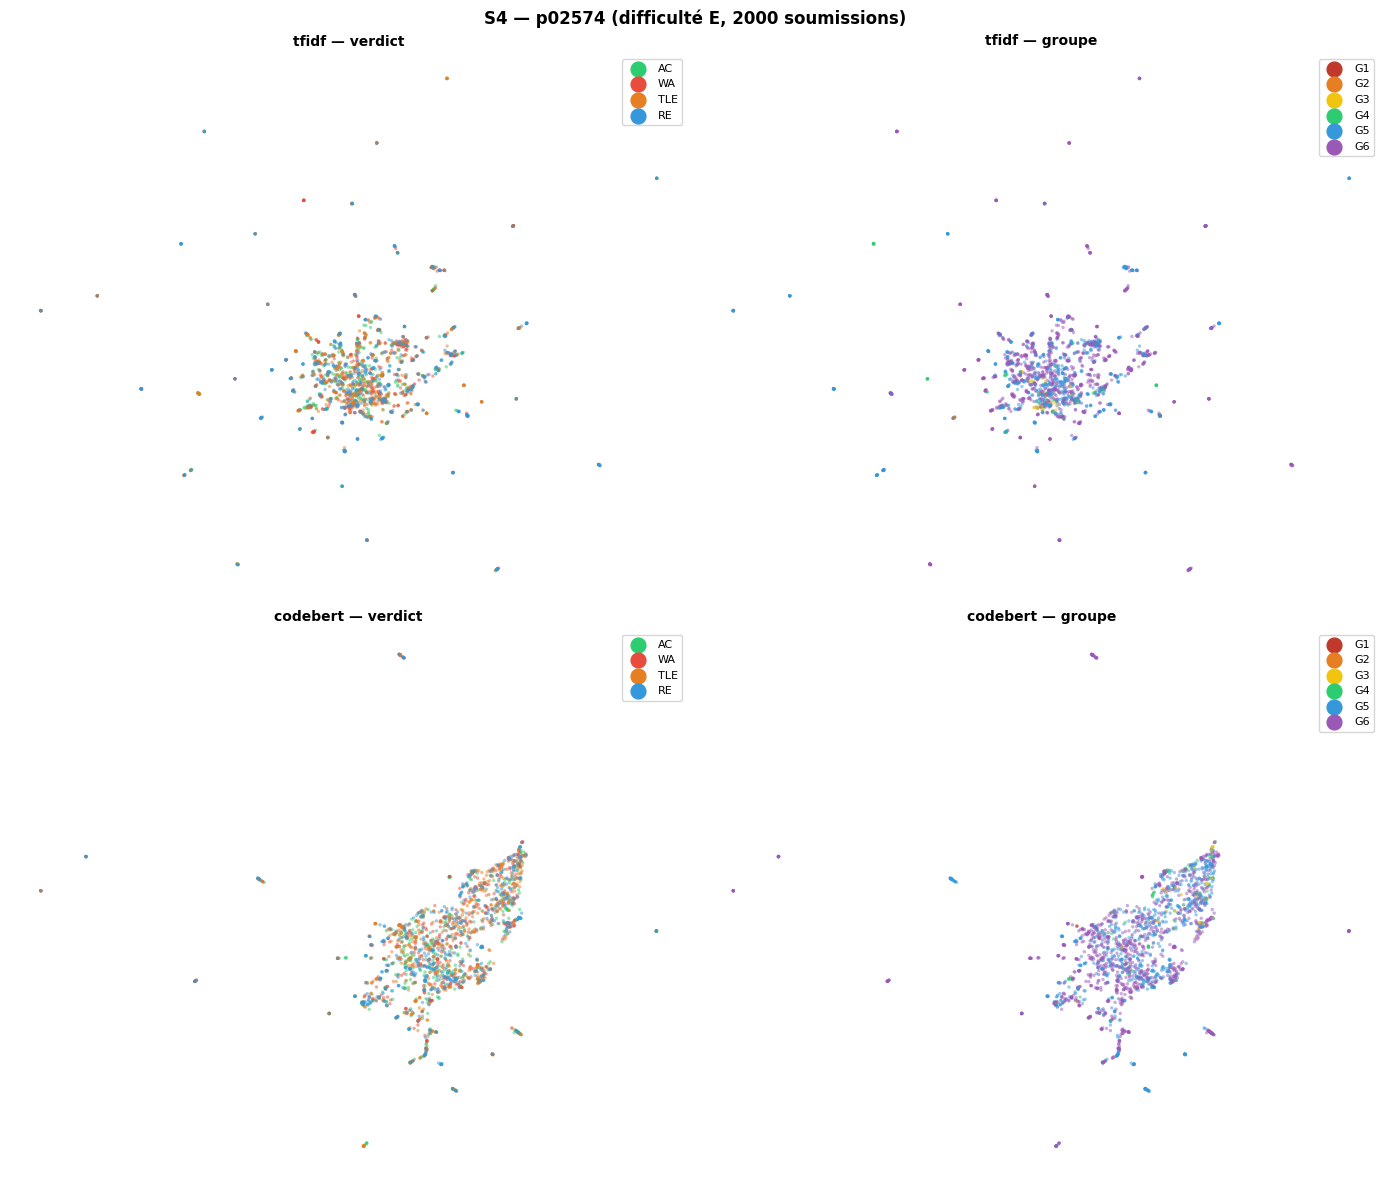

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


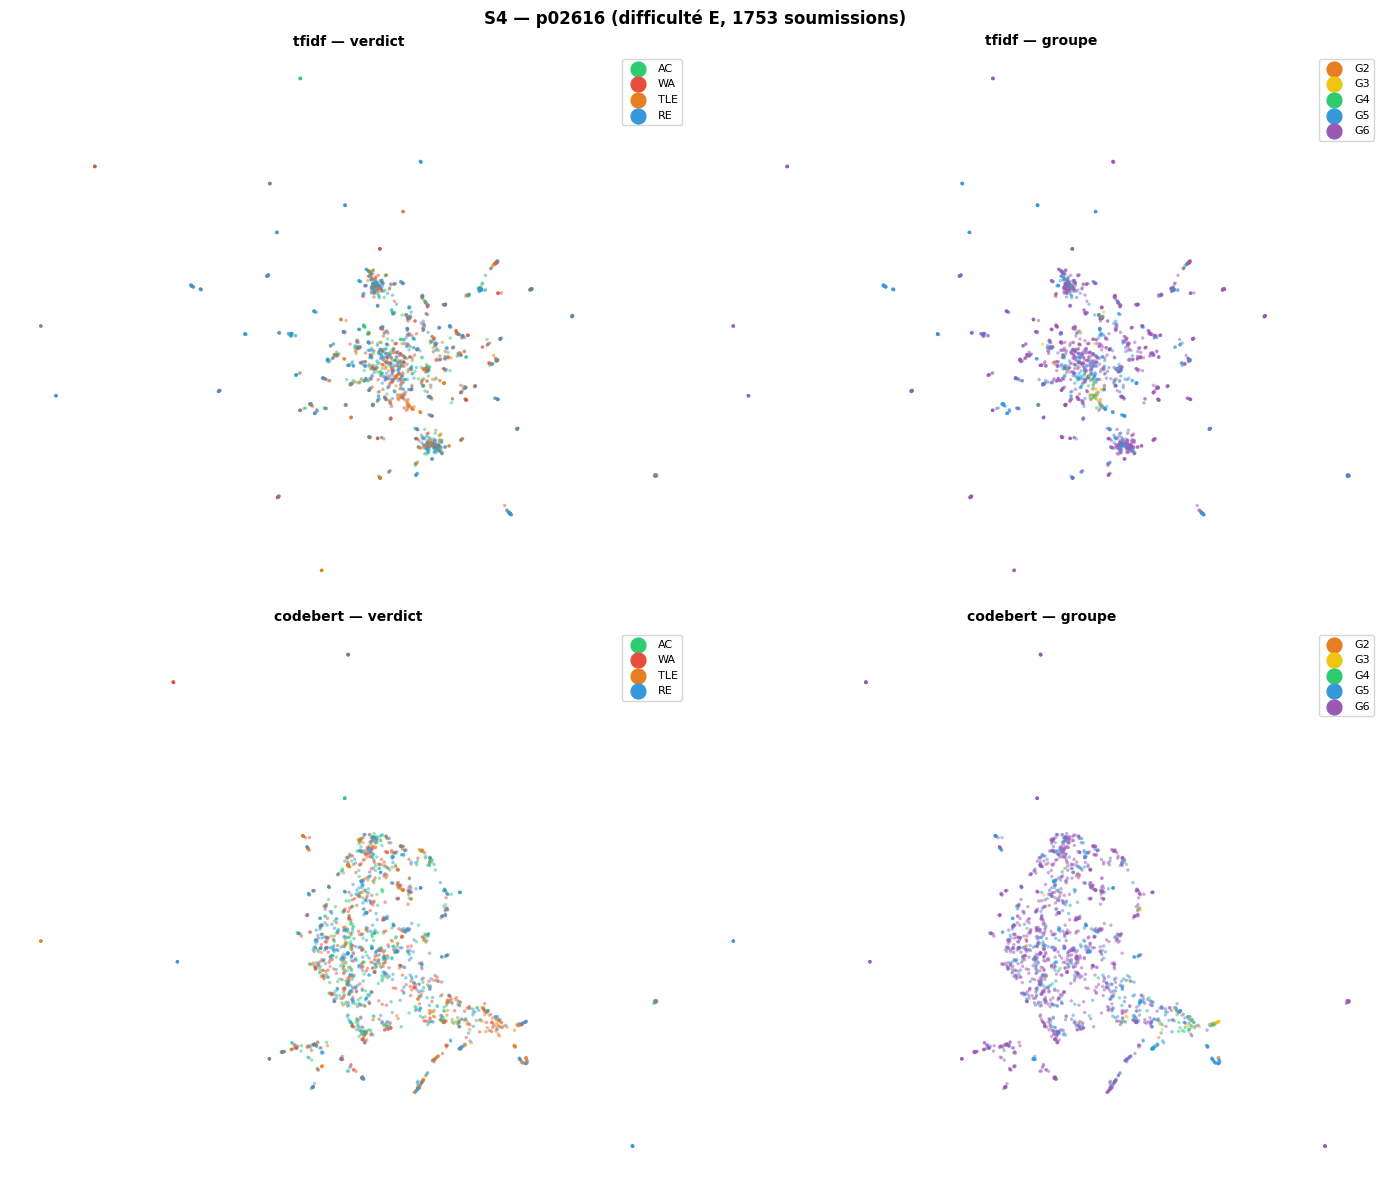

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


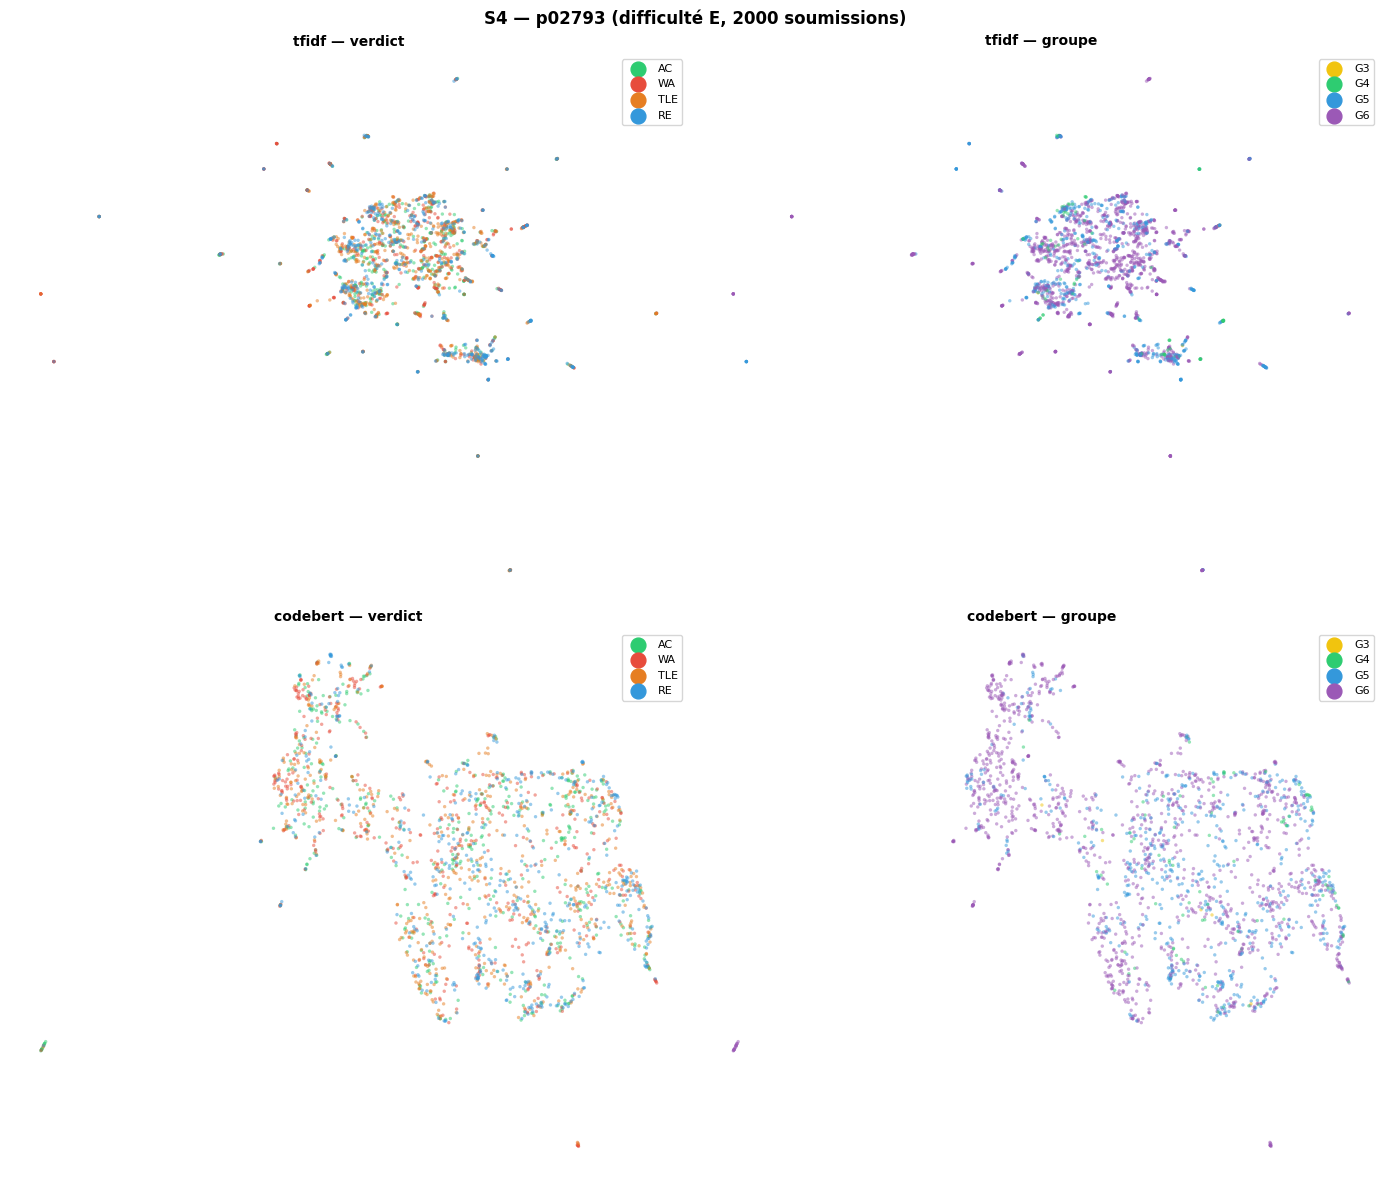

In [6]:
from IPython.display import display, Markdown

# Repère de lecture : extrêmes du criblage S2, à garder en tête pendant la galerie
for label in TARGET_LABELS_S2:
    sub = df_s2.filter(pl.col('label') == label)
    if sub.height == 0:
        continue
    top = sub.sort('lift', descending=True).row(0, named=True)
    bot = sub.sort('lift').row(0, named=True)
    print(f"{LABEL_NAMES_S2[label]:8s} — lift le plus fort  : {top['problem_id']} (×{top['lift']:.2f}, {top['method']})")
    print(f"{LABEL_NAMES_S2[label]:8s} — lift le plus faible : {bot['problem_id']} (×{bot['lift']:.2f}, {bot['method']})")

methods_here = [m for m in METHODS_MULTI if m in embeddings_multi]
label_style = {
    'status_code':       (STATUS_COLORS, STATUSES_ORDER),
    'proficiency_group': (GROUP_COLORS, GROUPS_ORDER),
}

problems_by_diff = (
    df_s2.select(['problem_id', 'difficulty']).unique().sort(['difficulty', 'problem_id'])
)

try:
    import umap

    for diff in DIFFS_ORDER:
        pids_diff = problems_by_diff.filter(pl.col('difficulty') == diff)['problem_id'].to_list()
        if not pids_diff:
            continue
        display(Markdown(
            f"### Difficulté {diff} — {', '.join(pids_diff)}\n"
            f"### Difficulty {diff} — {', '.join(pids_diff)}"
        ))

        for pid in pids_diff:
            fig, axes = plt.subplots(len(methods_here), len(TARGET_LABELS_S2),
                                     figsize=(7 * len(TARGET_LABELS_S2), 6 * len(methods_here)))
            axes = np.atleast_2d(axes)
            if axes.shape != (len(methods_here), len(TARGET_LABELS_S2)):
                axes = axes.reshape(len(methods_here), len(TARGET_LABELS_S2))

            n_this = 0
            for row_i, m in enumerate(methods_here):
                meta = df_meta_multi[m]
                idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
                n_this = len(idx)
                if n_this < 15:
                    for col_i in range(len(TARGET_LABELS_S2)):
                        axes[row_i, col_i].text(0.5, 0.5, "trop peu de points",
                                                ha='center', va='center', fontsize=9)
                        axes[row_i, col_i].axis('off')
                    continue

                sub_emb  = embeddings_multi[m][idx]
                sub_meta = meta[idx]
                reducer  = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                                     random_state=42, metric='cosine')
                proj = reducer.fit_transform(sub_emb)

                for col_i, label in enumerate(TARGET_LABELS_S2):
                    ax = axes[row_i, col_i]
                    colors_map, order = label_style[label]
                    vals = sub_meta[label].to_list()
                    ax.scatter(proj[:, 0], proj[:, 1],
                              c=[colors_map.get(v, '#aaaaaa') for v in vals],
                              s=6, alpha=0.5, linewidths=0)
                    for v in order:
                        if v in vals:
                            ax.scatter([], [], c=colors_map[v], s=35, label=v)
                    ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
                    ax.set_title(f'{m.replace("_python_multi12", "")} — {LABEL_NAMES_S2[label]}',
                                fontsize=10, fontweight='bold')
                    ax.axis('off')

            plt.suptitle(f'S4 — {pid} (difficulté {diff}, {n_this} soumissions)',
                         fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

except ImportError:
    print("UMAP non installé — pip install umap-learn")

## S5 — Synthèse
### S5 — Synthesis

| Question | Réponse |
|---|---|
| Le résultat de NB10 (aucun avantage CodeBERT sur TF-IDF) se généralise-t-il aux 12 problèmes ? | Oui. Sur le verdict, CodeBERT gagne sur 5/12 problèmes et perd sur 7, sans tendance systématique (moyenne ×1,35 contre ×1,37 pour TF-IDF, quasi égalité tirée par deux extrêmes qui se compensent : p02659 à −0,41, p02658 à +0,26). Sur le groupe, TF-IDF gagne sur 11/12 problèmes — une généralisation encore plus nette que sur le seul p02616 de NB10. |
| Le lift verdict suit-il la difficulté (croissant B→E, ou plat) ? | Non, aucune tendance monotone. Lift verdict moyen : ×1,34 (B) → ×1,42 (C) → ×1,39 (D) → ×1,28 (E) ; motif similaire en creux pour le groupe. Le signal reste globalement plat, indépendant de la difficulté. |
| Le groupe de compétence montre-t-il un signal plus net que le verdict ? | Non — plutôt l'inverse en moyenne (verdict ×1,36 contre groupe ×1,24). Exception notable à la difficulté E : le groupe s'homogénéise fortement (dominance visible de G6 sur les cartes UMAP), mais cela ne se traduit pas par un lift élevé car la baseline monte presque autant que la cohérence. |
| Les problèmes extrêmes identifiés en S2 confirment-ils visuellement leur statut en S4 ? | Non. Même p02659 (lift verdict le plus élevé du tableau, ×1,87) ne montre aucune séparation de couleur visible à l'œil dans sa figure S4. Ce résultat valide a posteriori le choix méthodologique de se fier au lift plutôt qu'à l'inspection visuelle des cartes. |

**Conclusion.** Ce résultat n'est pas un échec de l'analyse : c'est un résultat négatif
solide, généralisé sur 12 problèmes et 4 niveaux de difficulté, qui borne précisément
ce que des embeddings gelés (TF-IDF, CodeBERT) peuvent capturer. Le signal réel mais
modeste (jamais nul, jamais fort) suggère que le verdict — une propriété d'exécution —
n'est que faiblement corrélé à la similarité lexicale/sémantique de surface du code ;
et que le groupe de compétence laisse une trace stylistique ténue mais cohérente,
mieux captée par TF-IDF (lexical) que par CodeBERT (sémantique) — cohérent avec l'idée
que le niveau se lit davantage dans le style que dans la logique. La suite naturelle
n'est pas de changer de méthode de réduction de dimension (le lift, base de cette
conclusion, est calculé indépendamment de toute projection 2D — voir discussion), mais
de changer d'encodeur : un modèle sensible à la structure d'exécution (GraphCodeBERT)
est le prochain test logique.

---

| Question | Answer |
|---|---|
| Does NB10's finding (no CodeBERT advantage over TF-IDF) generalize across the 12 problems? | Yes. On verdict, CodeBERT wins on 5/12 problems and loses on 7, with no systematic trend (average ×1.35 vs ×1.37 for TF-IDF, near parity driven by two offsetting extremes: p02659 at −0.41, p02658 at +0.26). On group, TF-IDF wins on 11/12 problems — an even cleaner generalization than NB10's single p02616 result. |
| Does verdict lift track difficulty (increasing B→E, or flat)? | No monotonic trend. Average verdict lift: ×1.34 (B) → ×1.42 (C) → ×1.39 (D) → ×1.28 (E); a similar dip-shaped pattern for group. The signal stays broadly flat regardless of difficulty. |
| Does proficiency group show a cleaner signal than verdict? | No — if anything the reverse on average (verdict ×1.36 vs group ×1.24). Notable exception at difficulty E: group homogenizes strongly (visible G6 dominance on the UMAP maps), but this doesn't translate into high lift since the baseline rises nearly as much as consistency. |
| Do the extreme problems flagged in S2 visually confirm their status in S4? | No. Even p02659 (the table's highest verdict lift, ×1.87) shows no visible color separation in its S4 figure. This result retroactively validates relying on lift rather than visual inspection of the maps. |

**Conclusion.** This is not an analysis failure: it is a solid negative result,
generalized across 12 problems and 4 difficulty levels, that precisely bounds what
frozen embeddings (TF-IDF, CodeBERT) can capture. The real but modest signal (never
zero, never strong) suggests that the verdict — a runtime property — is only weakly
correlated with the code's surface lexical/semantic similarity; and that proficiency
group leaves a faint but consistent stylistic trace, better captured by TF-IDF
(lexical) than CodeBERT (semantic) — consistent with skill showing up in style more
than in logic. The natural next step is not a different dimensionality-reduction
method (lift, the basis of this conclusion, is computed independently of any 2D
projection — see discussion), but a different encoder: a model sensitive to
execution structure (GraphCodeBERT) is the logical next test.

## S6 — Vérification de robustesse : la projection 2D est-elle en cause ?
### S6 — Robustness Check: Is the 2D Projection to Blame?

**D'où vient ce doute.** La galerie S4 ne montre, sur aucun des 12 problèmes, de
regroupement de couleur visible à l'œil --- pas même p02659, dont le lift verdict
(×1,87) est le plus élevé du tableau S2. Une question méthodologique légitime se
pose alors : cette absence de séparation visuelle reflète-t-elle un signal
réellement modeste, ou est-elle un artefact du choix de projection --- UMAP
écraserait-il une structure locale plus forte que ce que l'œil peut voir ?

**Ce qui ne dépend pas de la projection.** Avant de répondre, un fait à établir
clairement : le lift de S2 n'est **jamais** calculé sur une projection 2D. Il est
mesuré directement dans l'espace complet de l'embedding --- 10 000 dimensions pour
TF-IDF, 768 pour CodeBERT --- via k-NN en distance cosinus. UMAP n'intervient
qu'ensuite, uniquement pour les figures S3 et S4. Autrement dit : quel que soit le
résultat des vérifications ci-dessous, la conclusion quantitative de S5 (signal réel
mais modeste) reste valide --- elle ne peut pas être invalidée par un problème de
projection, puisqu'elle ne passe par aucune projection. Ce que ces vérifications
peuvent apporter, c'est une réponse à une question plus étroite : notre incapacité
à *voir* ce signal est-elle spécifique à UMAP, ou persiste-t-elle avec d'autres
approches ?

**Deux vérifications, deux logiques différentes :**

1. **t-SNE** (S6.1) --- une seconde méthode de projection locale, avec un objectif
   mathématique différent d'UMAP (plongement probabiliste des voisinages plutôt
   qu'approximation de variété). Si UMAP en particulier ratait une structure que
   d'autres choix de projection révèlent, t-SNE a de bonnes chances de le montrer
   différemment.
2. **Heatmap de confusion par voisinage** (S6.2, reprise de la méthode de NB10
   S4.4) --- la vérification la plus rigoureuse des deux, car elle **ne passe par
   aucune projection**. Elle affiche directement, pour chaque étiquette réelle, la
   répartition des étiquettes des k plus proches voisins déjà calculés pour le lift
   de S2 --- la même information brute, simplement désagrégée par classe plutôt que
   moyennée en un seul chiffre.

**Ce qu'on attend, honnêtement.** Le lift de S2 étant déjà modeste (×1,2 à ×1,9,
jamais ×3 ou plus comme pour le clivage par problème), ces deux vérifications ne
visent pas à découvrir un signal caché spectaculaire --- l'objectif est de confirmer,
par deux voies indépendantes de la première, que l'absence de séparation visuelle en
S4 reflète bien un effet réellement modeste plutôt qu'un artefact de UMAP. Limité à
deux problèmes représentatifs pour rester une vérification rapide : **p02659** (lift
verdict le plus élevé --- le cas le plus favorable pour voir un signal si l'outil de
projection était en cause) et **p02658** (seul cas où CodeBERT dépasse nettement
TF-IDF sur le verdict).

---

**Where this doubt comes from.** The S4 gallery shows no visually noticeable color
clustering on any of the 12 problems --- not even p02659, whose verdict lift (×1.87)
is the highest in the S2 table. A legitimate methodological question follows: does
this lack of visual separation reflect a genuinely modest signal, or is it an
artifact of the projection choice --- could UMAP be collapsing a stronger local
structure than the eye can see?

**What does not depend on the projection.** Before answering, one fact needs to be
stated clearly: S2's lift is **never** computed on a 2D projection. It is measured
directly in the full embedding space --- 10,000 dimensions for TF-IDF, 768 for
CodeBERT --- via cosine k-NN. UMAP only enters afterward, solely for the S3 and S4
figures. In other words: whatever the checks below show, S5's quantitative
conclusion (a real but modest signal) remains valid --- it cannot be invalidated by
a projection issue, since it never goes through any projection. What these checks
can address is a narrower question: is our inability to *see* this signal specific
to UMAP, or does it persist under other approaches too?

**Two checks, two different logics:**

1. **t-SNE** (S6.1) --- a second local-projection method, with a different
   mathematical objective than UMAP (probabilistic neighbor embedding rather than
   manifold approximation). If UMAP specifically missed a structure that other
   projection choices reveal, t-SNE has a reasonable chance of showing it
   differently.
2. **Neighbor confusion heatmap** (S6.2, reusing NB10 S4.4's method) --- the more
   rigorous of the two checks, since it involves **no projection at all**. It
   directly displays, for each true label, the label distribution of the same k
   nearest neighbors already computed for S2's lift --- the same raw information,
   simply broken down by class instead of averaged into a single number.

**What we honestly expect.** Since S2's lift is already modest (×1.2 to ×1.9, never
×3 or more like the problem-level split), these two checks are not aimed at
discovering a spectacular hidden signal --- the goal is to confirm, via two paths
independent of the first, that the lack of visual separation in S4 reflects a
genuinely modest effect rather than a UMAP artifact. Limited to two representative
problems to keep this a quick check: **p02659** (highest verdict lift --- the most
favorable case for seeing a signal if the projection tool were at fault) and
**p02658** (the only case where CodeBERT clearly beats TF-IDF on verdict).

### S6.1 --- t-SNE, comparaison directe avec les panneaux UMAP de S4
#### S6.1 --- t-SNE, Direct Comparison with S4's UMAP Panels

Mêmes deux problèmes, même disposition (méthode en ligne, étiquette en colonne) que
S4, pour une comparaison visuelle directe panneau par panneau.

---

Same two problems, same layout (method as rows, label as columns) as S4, for a
direct panel-by-panel visual comparison.

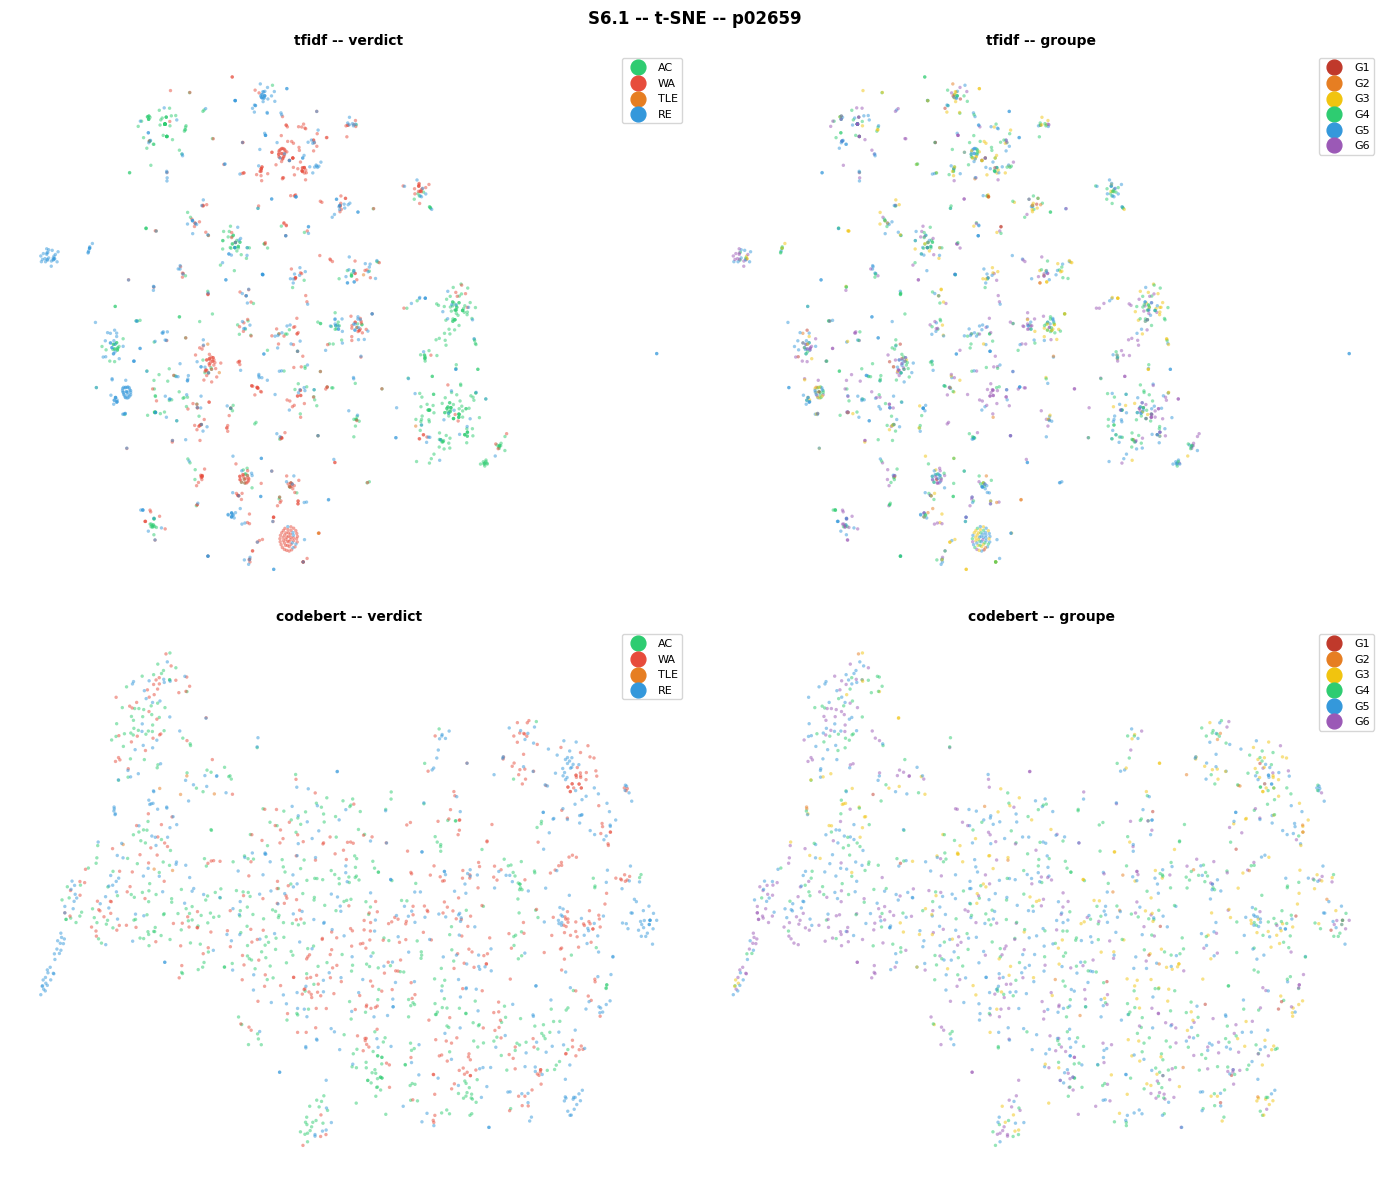

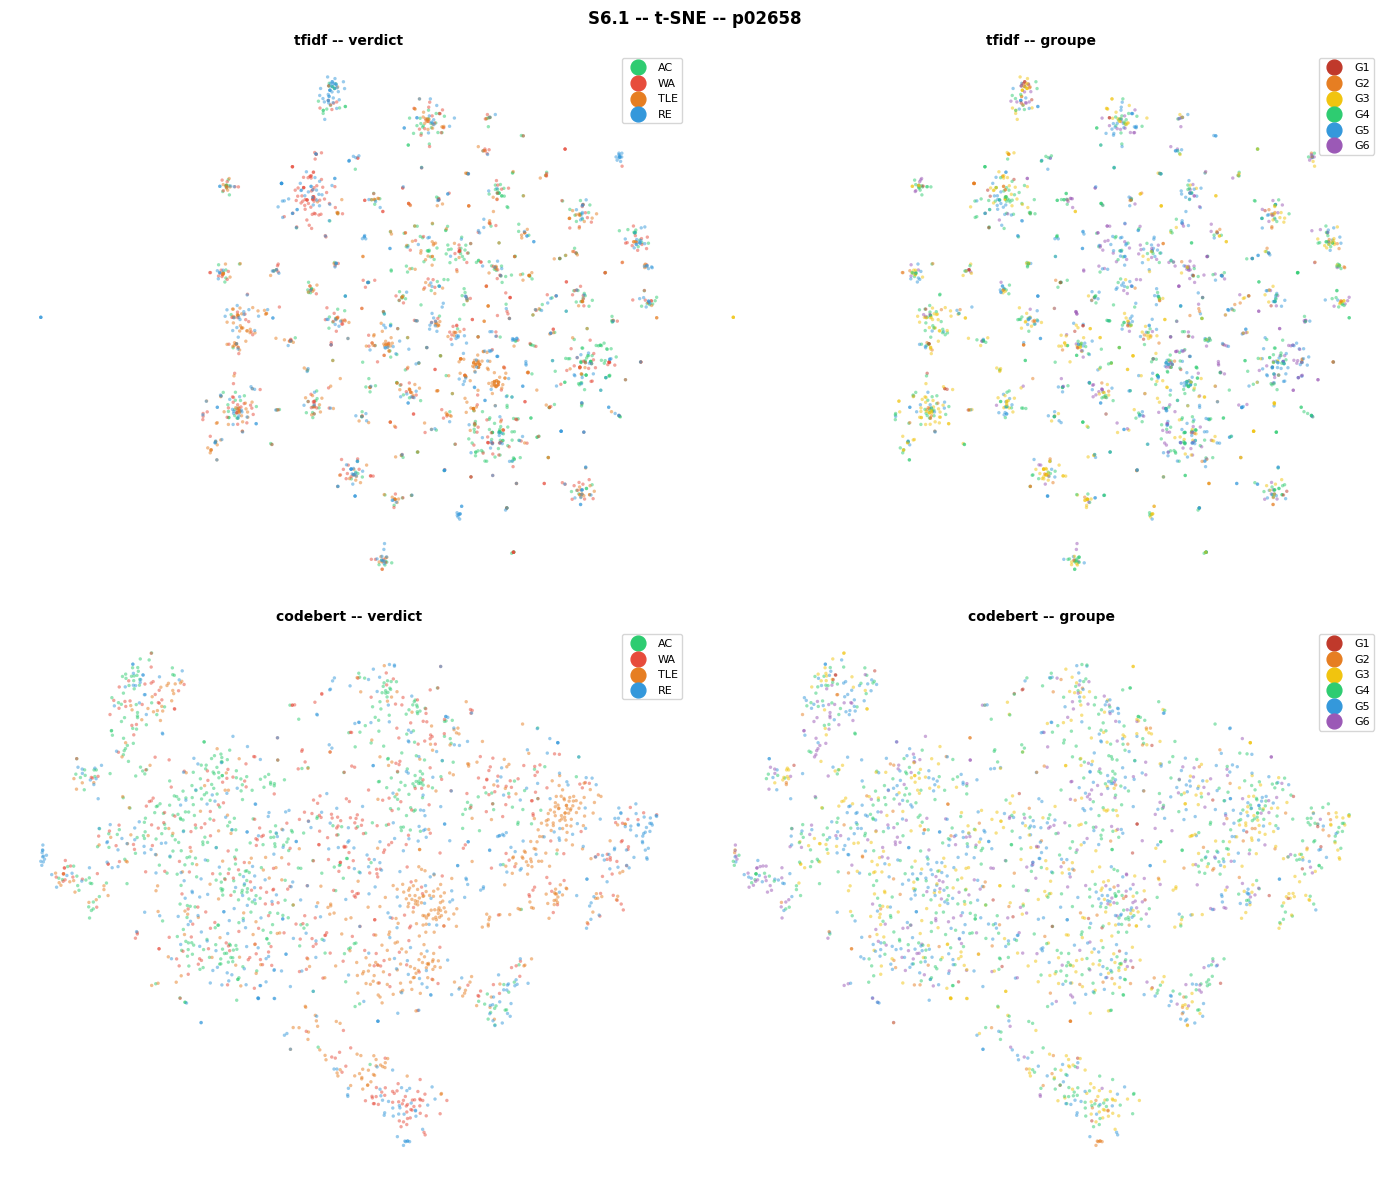

In [7]:
from sklearn.manifold import TSNE

TARGETS_S6 = ['p02659', 'p02658']  # lift verdict le plus fort / meilleur cas CodeBERT

for pid in TARGETS_S6:
    fig, axes = plt.subplots(len(methods_here), len(TARGET_LABELS_S2),
                             figsize=(7 * len(TARGET_LABELS_S2), 6 * len(methods_here)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_here), len(TARGET_LABELS_S2)):
        axes = axes.reshape(len(methods_here), len(TARGET_LABELS_S2))

    for row_i, m in enumerate(methods_here):
        meta = df_meta_multi[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_multi[m][idx]
        sub_meta = meta[idx]

        tsne = TSNE(n_components=2, random_state=42, metric='cosine', init='pca')
        proj = tsne.fit_transform(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS_S2):
            ax = axes[row_i, col_i]
            colors_map, order = label_style[label]
            vals = sub_meta[label].to_list()
            ax.scatter(proj[:, 0], proj[:, 1],
                      c=[colors_map.get(v, '#aaaaaa') for v in vals],
                      s=6, alpha=0.5, linewidths=0)
            for v in order:
                if v in vals:
                    ax.scatter([], [], c=colors_map[v], s=35, label=v)
            ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
            ax.set_title(f'{m.replace("_python_multi12", "")} -- {LABEL_NAMES_S2[label]}',
                        fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.suptitle(f'S6.1 -- t-SNE -- {pid}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### S6.2 --- Heatmap de confusion par voisinage (sans projection)
#### S6.2 --- Neighbor Confusion Heatmap (No Projection)

Pour chaque étiquette réelle, fraction des k=10 plus proches voisins (calculés dans
l'espace complet, comme pour S2) partageant chaque valeur possible de l'étiquette.
Diagonale forte = signal concentré et cohérent ; diagonale faible et uniforme =
signal diffus, cohérent avec un lift modeste.

---

For each true label, the fraction of the k=10 nearest neighbors (computed in the
full space, as for S2) sharing each possible label value. Strong diagonal =
concentrated, coherent signal; weak, uniform diagonal = diffuse signal, consistent
with a modest lift.

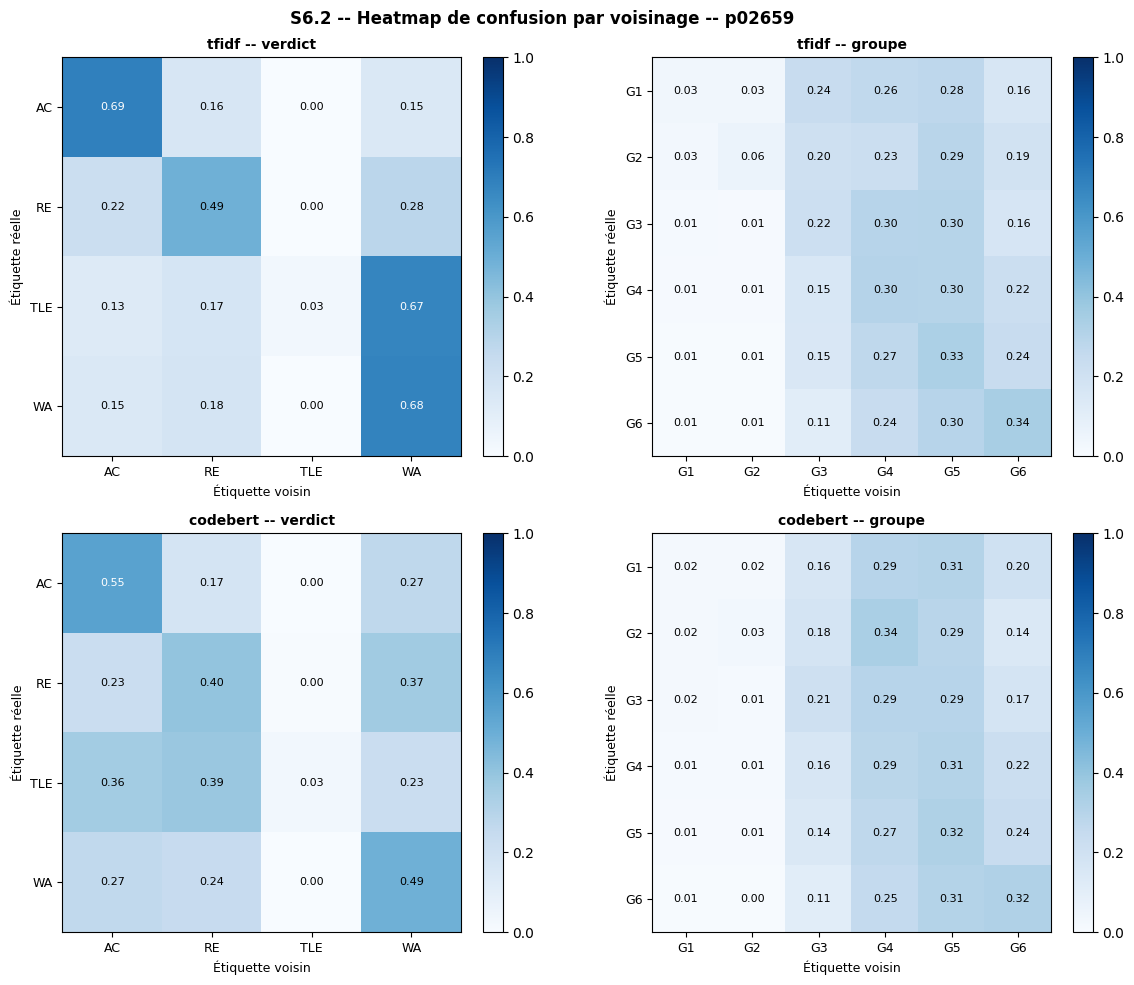

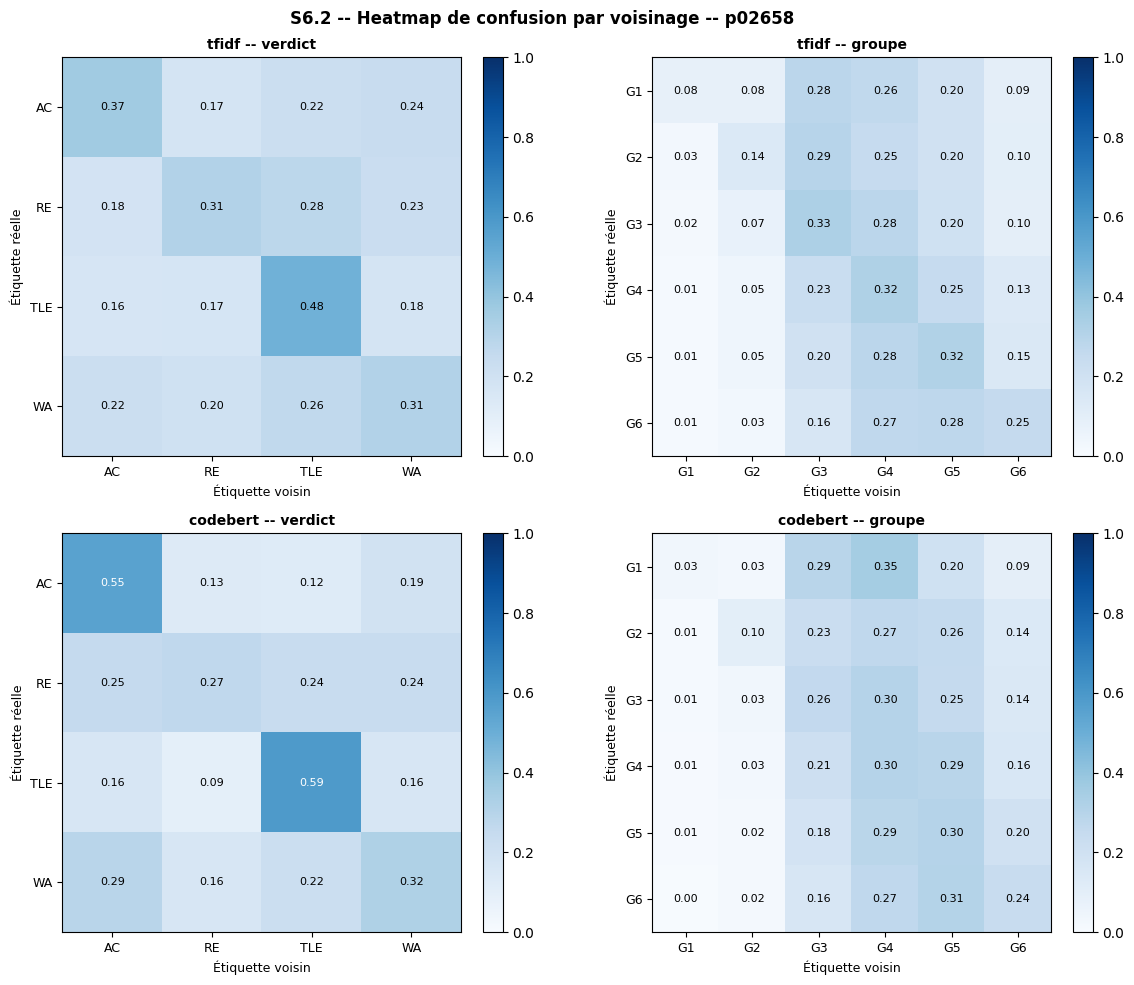

In [8]:
from sklearn.neighbors import NearestNeighbors as _NNs6

for pid in TARGETS_S6:
    fig, axes = plt.subplots(len(methods_here), len(TARGET_LABELS_S2),
                             figsize=(6 * len(TARGET_LABELS_S2), 5 * len(methods_here)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_here), len(TARGET_LABELS_S2)):
        axes = axes.reshape(len(methods_here), len(TARGET_LABELS_S2))

    for row_i, m in enumerate(methods_here):
        meta = df_meta_multi[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_multi[m][idx]
        sub_meta = meta[idx]

        nbrs = _NNs6(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS_S2):
            ax = axes[row_i, col_i]
            labels_arr = sub_meta[label].to_numpy()
            classes = sorted(set(labels_arr))
            cls_idx = {c: i for i, c in enumerate(classes)}
            n_cls = len(classes)

            matrix = np.zeros((n_cls, n_cls), dtype=float)
            for i, true_v in enumerate(labels_arr):
                for j in nn_idx[i, 1:]:
                    matrix[cls_idx[true_v], cls_idx[labels_arr[j]]] += 1
            row_sums = matrix.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            matrix /= row_sums

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(n_cls)); ax.set_xticklabels(classes, fontsize=9)
            ax.set_yticks(range(n_cls)); ax.set_yticklabels(classes, fontsize=9)
            ax.set_xlabel('Étiquette voisin', fontsize=9)
            ax.set_ylabel('Étiquette réelle', fontsize=9)
            ax.set_title(f'{m.replace("_python_multi12", "")} -- {LABEL_NAMES_S2[label]}',
                        fontsize=10, fontweight='bold')
            for r in range(n_cls):
                for c in range(n_cls):
                    ax.text(c, r, f'{matrix[r,c]:.2f}', ha='center', va='center',
                            fontsize=8, color='white' if matrix[r,c] > 0.5 else 'black')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'S6.2 -- Heatmap de confusion par voisinage -- {pid}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### S6.3 --- Conclusion de la vérification
#### S6.3 --- Verification Conclusion

Contrairement à l'attente initiale (« confirmation simple, rien de nouveau »), les
deux vérifications apportent une vraie nuance. Sur p02659 (tfidf, verdict), t-SNE ne
montre pas un blob uniforme comme UMAP en S4, mais de nombreux **petits îlots
compacts**, dont plusieurs sont visiblement dominés par une seule couleur (WA en
rouge, RE en bleu, AC en vert par endroits) --- une structure locale que le mode de
projection d'UMAP (plus continu, plus soucieux de préserver une structure globale
connectée) avait lissée. La heatmap de confusion (S6.2, sans aucune projection)
raconte exactement la même histoire en chiffres : sur ce même problème, AC et WA ont
un voisinage très cohérent (69 % et 68 % des 10 plus proches voisins partagent
l'étiquette), tandis que TLE est presque invisible (3 %). Le lift moyen (×1,87)
mélangeait ces deux réalités en un seul chiffre.

Ça ne change pas la conclusion de S5 (CodeBERT n'apporte toujours pas d'avantage
systématique --- ses diagonales de confusion sont globalement plus basses que celles
de TF-IDF sur p02659), mais ça la précise : le signal n'est pas diffus et uniforme,
il est concentré dans des poches locales spécifiques à certaines classes. UMAP avait
raison sur le fond (pas de séparation globale spectaculaire) mais lissait une
granularité locale réelle que t-SNE et la heatmap révèlent mieux. Pour la suite
(GraphCodeBERT), il vaudra mieux comparer les diagonales de confusion par classe
plutôt que le seul lift moyen --- c'est cette vue-là qui aurait le plus de chances de
détecter un vrai progrès localisé.

---

Contrary to the initial expectation ("simple confirmation, nothing new"), both
checks add a genuine nuance. On p02659 (tfidf, verdict), t-SNE does not show a
uniform blob like UMAP in S4, but many **small, tight islands**, several of which
are visibly dominated by a single color (red WA, blue RE, green AC in places) --- a
local structure that UMAP's projection style (more continuous, more concerned with
preserving a connected global structure) had smoothed away. The confusion heatmap
(S6.2, with no projection at all) tells exactly the same story numerically: on this
same problem, AC and WA have a highly coherent neighborhood (69% and 68% of the 10
nearest neighbors share the label), while TLE is nearly invisible (3%). The averaged
lift (×1.87) blended these two realities into a single number.

This does not change S5's conclusion (CodeBERT still shows no systematic advantage
--- its confusion diagonals are generally lower than TF-IDF's on p02659), but it
sharpens it: the signal is not diffuse and uniform, it is concentrated in local
pockets specific to certain classes. UMAP was right on the substance (no spectacular
global separation) but smoothed over a real local granularity that t-SNE and the
heatmap reveal more clearly. Going forward (GraphCodeBERT), it will be more
informative to compare per-class confusion diagonals rather than the single averaged
lift --- that view has the best chance of detecting a genuine, localized
improvement.